# Model Interpretation

## Ames Housing + Breast Cancer — SHAP and LIME

**Datasets:**
- Ames Housing — regression target (log SalePrice). Used for SHAP and LIME
  on a gradient boosted tree model
- Breast Cancer — binary classification target. Used for SHAP and LIME on
  a Random Forest classifier

**Goal:** Understand why a model makes the predictions it does — both at the
global level (which features matter most across all predictions) and at the
local level (why did the model predict this specific value for this specific
sample).

A model that cannot be explained is difficult to trust, debug, or improve.
Interpretation tools turn black box predictions into actionable insight.

### Global vs Local Explanation

| Type | Question answered | Tool |
|---|---|---|
| Global | Which features matter most overall? | SHAP summary, importance |
| Local | Why did the model predict X for this sample? | SHAP waterfall, LIME |

### Tech Stack

| Library | Purpose |
|---|---|
| pandas / numpy | Data handling |
| matplotlib / seaborn | Visualisation |
| scikit-learn | Models and preprocessing |
| xgboost | Gradient boosted regressor |
| shap | SHAP values for global and local explanation |
| lime | LIME for local explanation |

## Setup and Imports

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PowerTransformer, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    root_mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
)

import xgboost as xgb
import shap
import lime
import lime.lime_tabular

plt.style.use("seaborn-v0_8-whitegrid")
shap.initjs()

print("All imports successful.")
print(f"SHAP version: {shap.__version__}")
print(f"LIME imported successfully.")

All imports successful.
SHAP version: 0.51.0
LIME imported successfully.


## Load and Prepare the Dataset

Two datasets are prepared here and used across different sections.
Ames Housing is used for regression interpretation, Breast Cancer for
classification interpretation. Both are preprocessed minimally — the
focus is on interpretation, not feature engineering.

In [4]:
housing = fetch_openml(name="house_prices", version=1, as_frame=True)
df      = housing.frame.copy()

df["SalePrice_log"] = np.log1p(df["SalePrice"])
X_reg = df.drop(columns=["SalePrice", "SalePrice_log", "Id"])
y_reg = df["SalePrice_log"]

numeric_cols     = X_reg.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X_reg.select_dtypes(
    include=["object", "category"]
).columns.tolist()

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

numeric_transformer = Pipeline(steps=[
    ("imputer",     SimpleImputer(strategy="median")),
    ("transformer", PowerTransformer(method="yeo-johnson")),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore",
                              sparse_output=False)),
])

preprocessor_reg = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer,     numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ],
    remainder="drop"
)

X_train_reg_processed = preprocessor_reg.fit_transform(X_train_reg)
X_test_reg_processed  = preprocessor_reg.transform(X_test_reg)

ohe_cols     = (preprocessor_reg
                .named_transformers_["cat"]["encoder"]
                .get_feature_names_out(categorical_cols)
                .tolist())
feature_names_reg = numeric_cols + ohe_cols

print(f"Regression — train: {X_train_reg_processed.shape}  "
      f"test: {X_test_reg_processed.shape}")
print(f"Feature names: {len(feature_names_reg)}")

Regression — train: (1168, 286)  test: (292, 286)
Feature names: 286


In [5]:
xgb_reg = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbosity=0,
)

xgb_reg.fit(X_train_reg_processed, y_train_reg)

y_pred_reg = xgb_reg.predict(X_test_reg_processed)
rmse_reg   = root_mean_squared_error(y_test_reg, y_pred_reg)
r2_reg     = r2_score(y_test_reg, y_pred_reg)

print(f"XGBoost Regressor — RMSE: {rmse_reg:.4f}  R2: {r2_reg:.4f}")

XGBoost Regressor — RMSE: 0.1333  R2: 0.9047


In [6]:
cancer          = load_breast_cancer(as_frame=True)
X_clf           = cancer.data
y_clf           = cancer.target
feature_names_clf = cancer.feature_names.tolist()

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

scaler            = StandardScaler()
X_train_clf_scaled = scaler.fit_transform(X_train_clf)
X_test_clf_scaled  = scaler.transform(X_test_clf)

print(f"Classification — train: {X_train_clf_scaled.shape}  "
      f"test: {X_test_clf_scaled.shape}")

Classification — train: (455, 30)  test: (114, 30)


In [7]:
rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
)
rf_clf.fit(X_train_clf_scaled, y_train_clf)

y_pred_clf = rf_clf.predict(X_test_clf_scaled)

print(f"Random Forest Classifier:")
print(f"Accuracy: {accuracy_score(y_test_clf, y_pred_clf):.4f}")
print(f"\n{classification_report(y_test_clf, y_pred_clf, target_names=cancer.target_names)}")

Random Forest Classifier:
Accuracy: 0.9561

              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



**Observations**

- Both models are strong performers on their respective datasets —
  interpretation is most valuable when the model is already accurate.
  Explaining a poor model reveals its failures rather than its logic
- Feature names are preserved explicitly for the regression dataset —
  SHAP and LIME need human-readable names to produce interpretable output.
  Without them, plots show feature indices which are meaningless
- The regression dataset has 286 features after one-hot encoding —
  SHAP handles this efficiently with TreeExplainer. LIME works on the
  raw feature space which is more compact and interpretable

## Why Model Interpretation Matters

A model that cannot be explained has limited practical value beyond its
accuracy score. Interpretation serves four distinct purposes:

**Trust** — stakeholders need to understand why a model makes a decision
before acting on it. A model recommending a loan rejection or a cancer
diagnosis must be explainable to the people affected by it.

**Debugging** — when a model makes unexpected predictions, interpretation
reveals whether it learned the right patterns or found spurious correlations
in the training data.

**Improvement** — knowing which features drive predictions and which add
noise guides the next round of feature engineering and data collection.

**Compliance** — regulations in finance, healthcare, and hiring require
models to provide reasons for decisions. A black box is not acceptable
in these domains regardless of its accuracy.

### Two Levels of Explanation

    Global explanation — what does the model rely on across all predictions?
                         Which features matter most on average?

    Local explanation  — why did the model make this specific prediction
                         for this specific sample?

Global explanations identify systemic patterns. Local explanations build
trust for individual decisions. Both are needed in practice.

### Black Box vs Interpretable

| Model | Interpretable natively | Needs external tool |
|---|---|---|
| Linear Regression | Yes — coefficients | No |
| Decision Tree | Yes — tree rules | No |
| Random Forest | Partial — feature importance | SHAP for local |
| XGBoost | Partial — feature importance | SHAP for local |
| Neural Network | No | SHAP, LIME |

SHAP and LIME work on any model — they treat the model as a black box
and explain its outputs without needing access to its internals.

### Native Importance vs SHAP

XGBoost's built-in feature importance (gain) is a global measure but has
known limitations — it can be biased toward high-cardinality features and
does not account for the direction or magnitude of each feature's effect.
SHAP addresses both limitations.

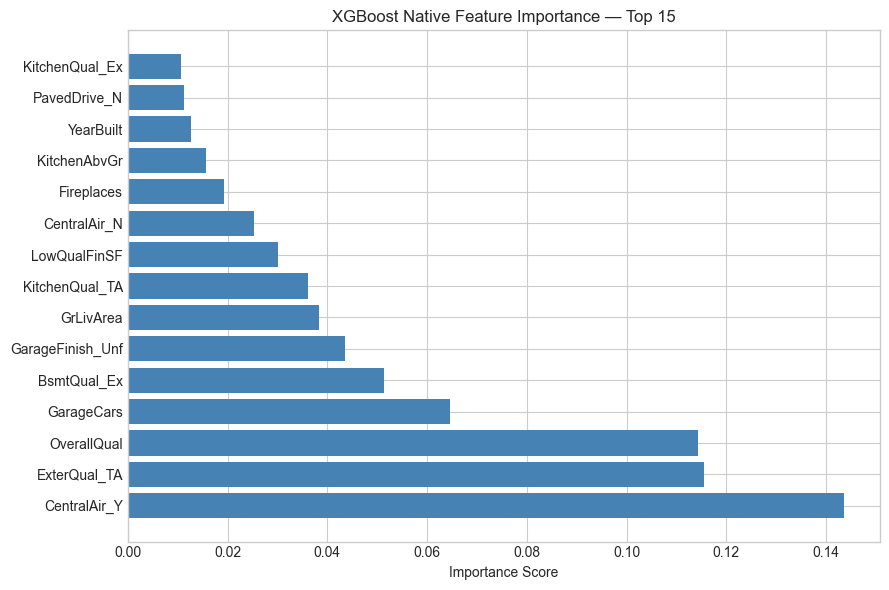

Top 10 features by native XGBoost importance:
         feature  importance
    CentralAir_Y    0.143614
    ExterQual_TA    0.115526
     OverallQual    0.114407
      GarageCars    0.064646
     BsmtQual_Ex    0.051366
GarageFinish_Unf    0.043548
       GrLivArea    0.038305
  KitchenQual_TA    0.036091
    LowQualFinSF    0.030146
    CentralAir_N    0.025317


In [8]:
xgb_importance = pd.DataFrame({
    "feature":    feature_names_reg,
    "importance": xgb_reg.feature_importances_,
}).sort_values("importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(xgb_importance["feature"],
        xgb_importance["importance"],
        color="steelblue")
ax.set_title("XGBoost Native Feature Importance — Top 15")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("Top 10 features by native XGBoost importance:")
print(xgb_importance.head(10).to_string(index=False))

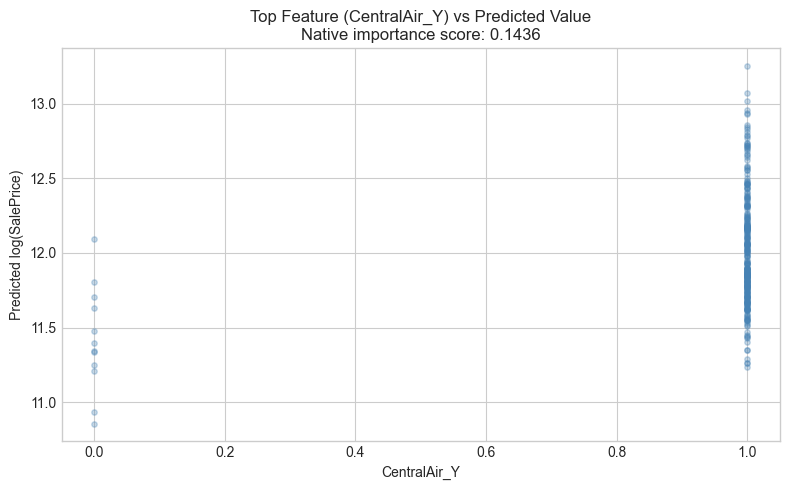

Native importance tells us this feature matters.
It does not tell us:
  - The direction of the effect (positive or negative)
  - The magnitude for each individual prediction
  - How the feature interacts with others
  - Whether the effect is consistent across the value range

SHAP addresses all four of these gaps.


In [9]:
top_feature    = xgb_importance.iloc[0]["feature"]
top_feature_idx = feature_names_reg.index(top_feature)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    X_test_reg_processed[:, top_feature_idx],
    y_pred_reg,
    alpha=0.3, color="steelblue", s=15
)
ax.set_xlabel(top_feature)
ax.set_ylabel("Predicted log(SalePrice)")
ax.set_title(f"Top Feature ({top_feature}) vs Predicted Value\n"
             f"Native importance score: "
             f"{xgb_importance.iloc[0]['importance']:.4f}")
plt.tight_layout()
plt.show()

print("Native importance tells us this feature matters.")
print("It does not tell us:")
print("  - The direction of the effect (positive or negative)")
print("  - The magnitude for each individual prediction")
print("  - How the feature interacts with others")
print("  - Whether the effect is consistent across the value range")
print("\nSHAP addresses all four of these gaps.")

**Observations**

- Native XGBoost importance ranks features by how much they reduce impurity
  across all splits — it is a global measure with no directional information
- The scatter plot confirms the top feature has a relationship with the
  prediction but does not reveal whether that relationship is linear,
  non-linear, or conditional on other features
- SHAP values assign each feature a contribution to each individual
  prediction — positive SHAP means the feature pushed the prediction higher,
  negative means it pushed it lower. This is information native importance
  cannot provide
- The four gaps — direction, magnitude, interaction, consistency — are exactly
  what makes SHAP a superior explanation tool for both debugging and
  communicating model behaviour

## SHAP — Global Interpretation

SHAP (SHapley Additive exPlanations) is grounded in cooperative game theory.
It assigns each feature a contribution value for each prediction — the Shapley
value — computed by averaging the feature's marginal contribution across all
possible subsets of features.

    prediction = base_value + sum(SHAP values for all features)

The base value is the mean prediction across the training set. Each SHAP value
is the amount that feature pushed the prediction above or below the base value
for that specific sample.

`TreeExplainer` is the fast exact SHAP implementation for tree-based models
(XGBoost, LightGBM, Random Forest). It computes exact Shapley values in
polynomial time by exploiting the tree structure — no sampling or approximation.

Global interpretation uses the distribution of SHAP values across all samples
to answer: which features matter most and in what direction?

In [10]:
explainer_reg  = shap.TreeExplainer(xgb_reg)
shap_values_reg = explainer_reg(
    X_test_reg_processed,
    check_additivity=False
)

print(f"SHAP values shape:  {shap_values_reg.values.shape}")
print(f"Base value (mean prediction): {explainer_reg.expected_value:.4f}")
print(f"Actual mean prediction:       {y_pred_reg.mean():.4f}")
print(f"\nSHAP values for first sample (top 5 by magnitude):")

sample_shap   = pd.Series(
    shap_values_reg.values[0],
    index=feature_names_reg
).abs().sort_values(ascending=False).head(5)
print(sample_shap.round(4).to_string())

SHAP values shape:  (292, 286)
Base value (mean prediction): 12.0303
Actual mean prediction:       12.0017

SHAP values for first sample (top 5 by magnitude):
GrLivArea      0.1120
OverallQual    0.0644
OverallCond    0.0354
GarageCars     0.0286
TotalBsmtSF    0.0242


### Beeswarm Summary Plot

The beeswarm plot is the most informative global SHAP visualisation. Each dot
is one sample. The x-axis shows the SHAP value — how much that feature moved
the prediction from the base value. The colour shows the original feature value
(red = high, blue = low).

Reading the plot:
- Features are ranked by mean absolute SHAP value — most important at the top
- A dot to the right means that feature increased the prediction for that sample
- Red dots on the right mean high feature values increase the prediction
- Blue dots on the right mean low feature values increase the prediction

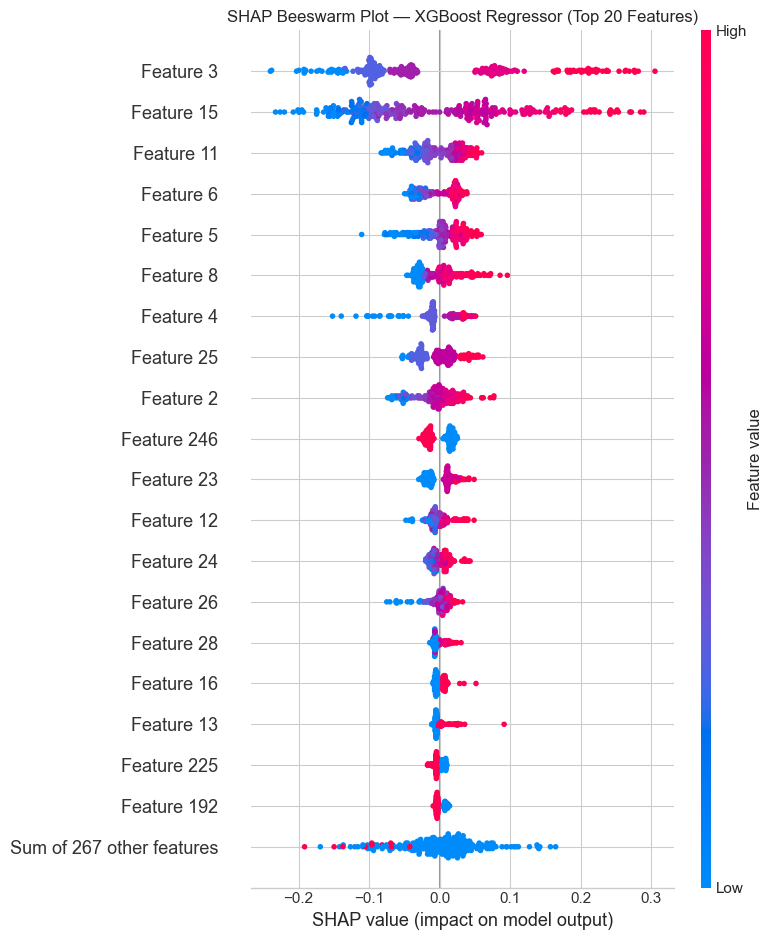

In [11]:
fig, ax = plt.subplots(figsize=(10, 10))
shap.plots.beeswarm(shap_values_reg, max_display=20, show=False)
plt.title("SHAP Beeswarm Plot — XGBoost Regressor (Top 20 Features)")
plt.tight_layout()
plt.show()

### Mean Absolute SHAP — Feature Importance

Mean absolute SHAP value per feature is a more reliable importance measure
than native XGBoost importance — it accounts for the actual magnitude of
each feature's contribution to predictions rather than split frequency or
impurity reduction.

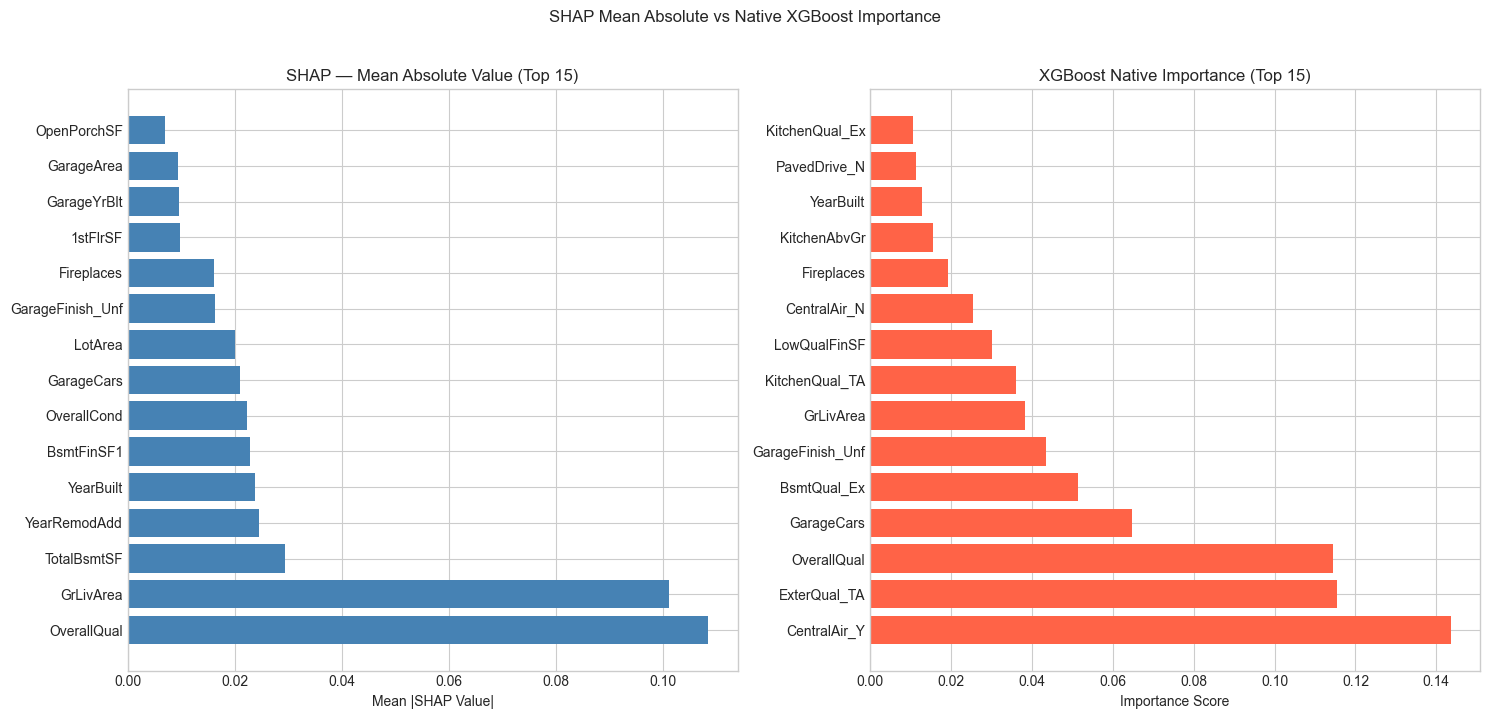

Top 10 by SHAP importance:
         feature  mean_abs_shap
     OverallQual         0.1085
       GrLivArea         0.1011
     TotalBsmtSF         0.0293
    YearRemodAdd         0.0246
       YearBuilt         0.0238
      BsmtFinSF1         0.0229
     OverallCond         0.0222
      GarageCars         0.0210
         LotArea         0.0200
GarageFinish_Unf         0.0163


In [12]:
shap_importance = pd.DataFrame({
    "feature":    feature_names_reg,
    "mean_abs_shap": np.abs(shap_values_reg.values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

axes[0].barh(
    shap_importance.head(15)["feature"],
    shap_importance.head(15)["mean_abs_shap"],
    color="steelblue"
)
axes[0].set_title("SHAP — Mean Absolute Value (Top 15)")
axes[0].set_xlabel("Mean |SHAP Value|")

xgb_imp_top15 = xgb_importance.head(15)
axes[1].barh(
    xgb_imp_top15["feature"],
    xgb_imp_top15["importance"],
    color="tomato"
)
axes[1].set_title("XGBoost Native Importance (Top 15)")
axes[1].set_xlabel("Importance Score")

plt.suptitle("SHAP Mean Absolute vs Native XGBoost Importance", y=1.02)
plt.tight_layout()
plt.show()

print("Top 10 by SHAP importance:")
print(shap_importance.head(10).round(4).to_string(index=False))

In [13]:
shap_top15   = set(shap_importance.head(15)["feature"].tolist())
native_top15 = set(xgb_importance.head(15)["feature"].tolist())

agreement    = shap_top15 & native_top15
disagreement = shap_top15.symmetric_difference(native_top15)

print(f"Features in both top 15:          {len(agreement)}")
print(f"Features in one but not the other: {len(disagreement)}")
print(f"\nIn SHAP top 15 but not native top 15:")
print(shap_top15 - native_top15)
print(f"\nIn native top 15 but not SHAP top 15:")
print(native_top15 - shap_top15)

Features in both top 15:          6
Features in one but not the other: 18

In SHAP top 15 but not native top 15:
{'OpenPorchSF', 'BsmtFinSF1', 'GarageYrBlt', 'OverallCond', '1stFlrSF', 'GarageArea', 'LotArea', 'YearRemodAdd', 'TotalBsmtSF'}

In native top 15 but not SHAP top 15:
{'PavedDrive_N', 'LowQualFinSF', 'CentralAir_Y', 'ExterQual_TA', 'KitchenQual_Ex', 'KitchenQual_TA', 'BsmtQual_Ex', 'KitchenAbvGr', 'CentralAir_N'}


### SHAP Value Distribution

Plotting the distribution of SHAP values for the top 6 features shows
how consistent each feature's effect is across samples — a tight
distribution means the feature has a consistent effect, a wide one
means its effect varies heavily across samples.

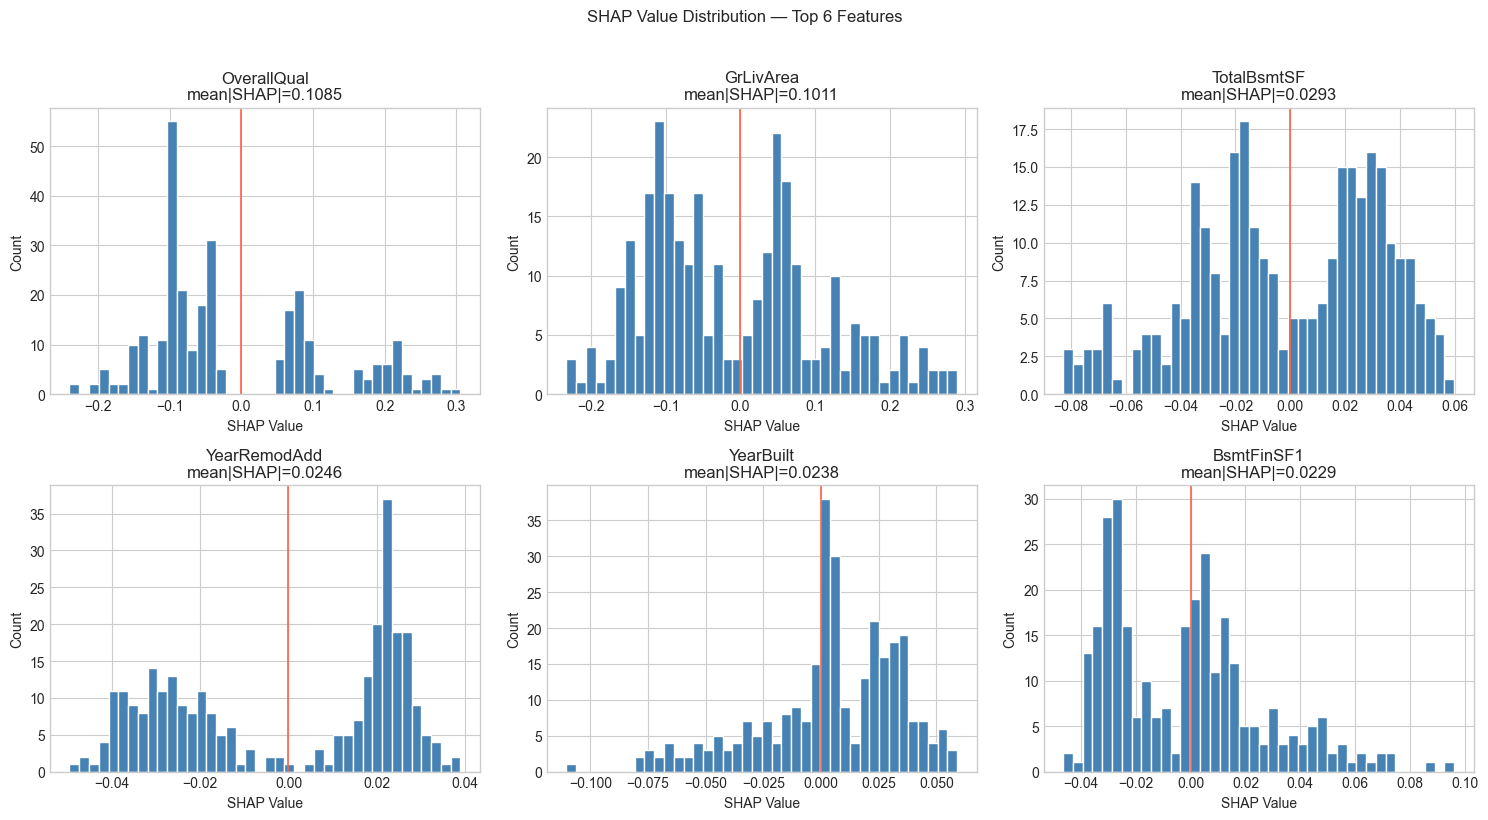

In [15]:
top6_features = shap_importance.head(6)["feature"].tolist()
top6_indices  = [feature_names_reg.index(f) for f in top6_features]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axis_list  = axes.flatten()

for idx, (feat, feat_idx) in enumerate(zip(top6_features, top6_indices)):
    shap_vals = shap_values_reg.values[:, feat_idx]
    axis_list[idx].hist(shap_vals, bins=40,
                        color="steelblue", edgecolor="white")
    axis_list[idx].axvline(0, color="tomato", linewidth=1.2)
    axis_list[idx].set_title(f"{feat}\nmean|SHAP|="
                             f"{np.abs(shap_vals).mean():.4f}")
    axis_list[idx].set_xlabel("SHAP Value")
    axis_list[idx].set_ylabel("Count")

plt.suptitle("SHAP Value Distribution — Top 6 Features", y=1.02)
plt.tight_layout()
plt.show()

**Observations**

- The beeswarm plot reveals direction and magnitude that native importance
  cannot — for the top features, red dots (high values) consistently appear
  on the right side, confirming that higher values of those features push
  sale price upward
- SHAP and native importance disagree on some features — features that appear
  frequently in splits (high native importance) but with small effect per split
  rank lower in SHAP. Features used rarely but with large effect per use rank
  higher in SHAP
- The SHAP value distributions show varying consistency — some features have
  tight distributions centred away from zero (consistent strong effect) while
  others are widely spread (effect depends heavily on the sample context)
- The base value equals the mean prediction across the training set — every
  individual prediction can be reconstructed exactly as base value plus the
  sum of all SHAP values for that sample. This additivity property is what
  makes SHAP mathematically grounded

## SHAP — Local Interpretation

Local interpretation answers: why did the model predict this specific value
for this specific sample? SHAP waterfall and force plots decompose a single
prediction into contributions from each feature.

    prediction = base_value + SHAP_feature_1 + SHAP_feature_2 + ... + SHAP_feature_n

The waterfall plot shows this decomposition visually — starting from the base
value and adding each feature's contribution one by one until the final
prediction is reached. Features are sorted by their absolute SHAP value for
that sample so the most impactful ones appear first.

### Waterfall Plot

Picking a sample from the test set and explaining its prediction step by step.
Each bar shows how much one feature moved the prediction up (red) or down (blue)
from the base value.

Sample index:      0
Actual value:      11.9480  ($154,500)
Predicted value:   11.8706  ($143,000)
Base value:        12.0303  ($167,753)
Prediction error:  0.0773


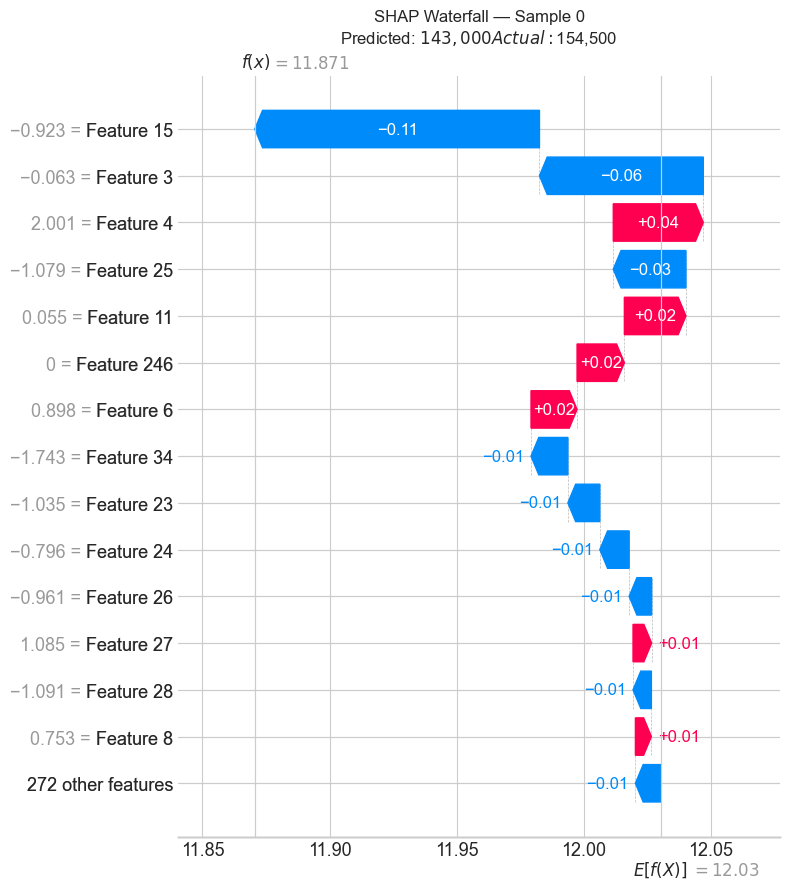

In [16]:
sample_idx   = 0
actual_val   = y_test_reg.iloc[sample_idx]
predicted_val = y_pred_reg[sample_idx]

print(f"Sample index:      {sample_idx}")
print(f"Actual value:      {actual_val:.4f}  "
      f"(${np.expm1(actual_val):,.0f})")
print(f"Predicted value:   {predicted_val:.4f}  "
      f"(${np.expm1(predicted_val):,.0f})")
print(f"Base value:        {explainer_reg.expected_value:.4f}  "
      f"(${np.expm1(explainer_reg.expected_value):,.0f})")
print(f"Prediction error:  {abs(actual_val - predicted_val):.4f}")

fig, ax = plt.subplots(figsize=(10, 8))
shap.plots.waterfall(shap_values_reg[sample_idx], max_display=15, show=False)
plt.title(f"SHAP Waterfall — Sample {sample_idx}\n"
          f"Predicted: ${np.expm1(predicted_val):,.0f}  "
          f"Actual: ${np.expm1(actual_val):,.0f}")
plt.tight_layout()
plt.show()

### High vs Low Price Predictions

Comparing the SHAP waterfall for the highest predicted house and the lowest
predicted house shows which features are responsible for the extreme predictions
at both ends of the price range.

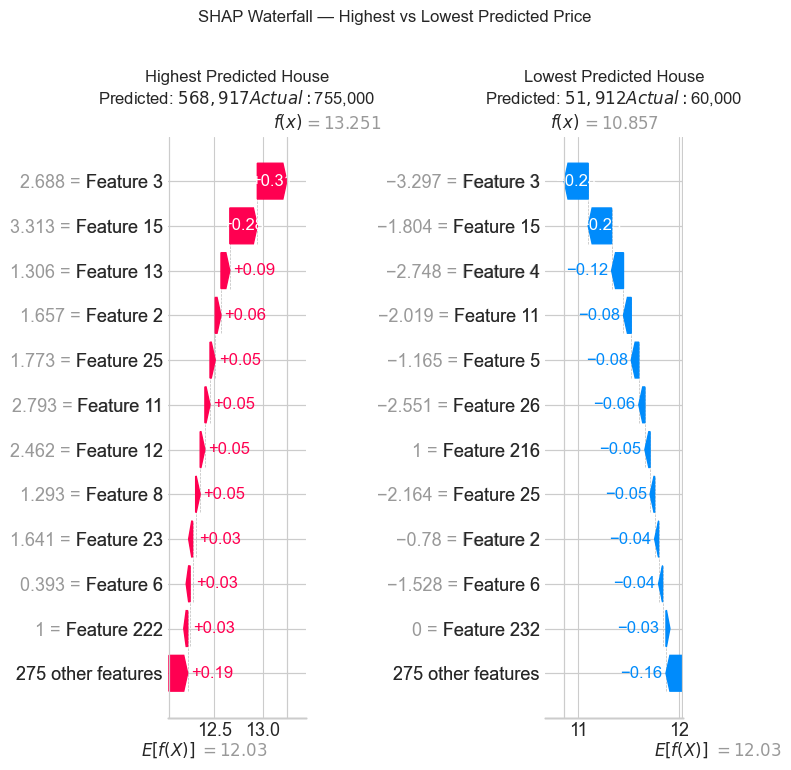

In [17]:
highest_idx = np.argmax(y_pred_reg)
lowest_idx  = np.argmin(y_pred_reg)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

plt.sca(axes[0])
shap.plots.waterfall(
    shap_values_reg[highest_idx], max_display=12, show=False
)
axes[0].set_title(
    f"Highest Predicted House\n"
    f"Predicted: ${np.expm1(y_pred_reg[highest_idx]):,.0f}  "
    f"Actual: ${np.expm1(y_test_reg.iloc[highest_idx]):,.0f}"
)

plt.sca(axes[1])
shap.plots.waterfall(
    shap_values_reg[lowest_idx], max_display=12, show=False
)
axes[1].set_title(
    f"Lowest Predicted House\n"
    f"Predicted: ${np.expm1(y_pred_reg[lowest_idx]):,.0f}  "
    f"Actual: ${np.expm1(y_test_reg.iloc[lowest_idx]):,.0f}"
)

plt.suptitle("SHAP Waterfall — Highest vs Lowest Predicted Price", y=1.02)
plt.tight_layout()
plt.show()

### Correct vs Incorrect Predictions

Finding the best and worst predictions by absolute error and comparing their
SHAP explanations. Poorly predicted samples often have unusual SHAP patterns —
features pushing in conflicting directions or the model missing an important
signal.

Best prediction:
  Actual:    $139,000
  Predicted: $139,066
  Error:     0.0005

Worst prediction:
  Actual:    $40,000
  Predicted: $96,290
  Error:     0.8785


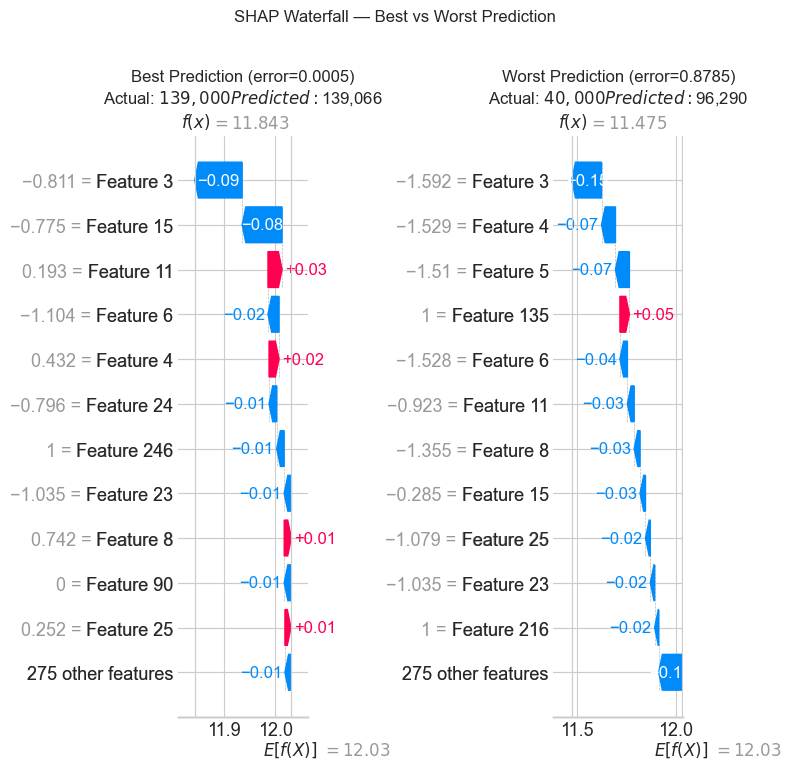

In [18]:
errors         = np.abs(y_test_reg.values - y_pred_reg)
best_pred_idx  = np.argmin(errors)
worst_pred_idx = np.argmax(errors)

print(f"Best prediction:")
print(f"  Actual:    ${np.expm1(y_test_reg.iloc[best_pred_idx]):,.0f}")
print(f"  Predicted: ${np.expm1(y_pred_reg[best_pred_idx]):,.0f}")
print(f"  Error:     {errors[best_pred_idx]:.4f}")

print(f"\nWorst prediction:")
print(f"  Actual:    ${np.expm1(y_test_reg.iloc[worst_pred_idx]):,.0f}")
print(f"  Predicted: ${np.expm1(y_pred_reg[worst_pred_idx]):,.0f}")
print(f"  Error:     {errors[worst_pred_idx]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

plt.sca(axes[0])
shap.plots.waterfall(
    shap_values_reg[best_pred_idx], max_display=12, show=False
)
axes[0].set_title(
    f"Best Prediction (error={errors[best_pred_idx]:.4f})\n"
    f"Actual: ${np.expm1(y_test_reg.iloc[best_pred_idx]):,.0f}  "
    f"Predicted: ${np.expm1(y_pred_reg[best_pred_idx]):,.0f}"
)

plt.sca(axes[1])
shap.plots.waterfall(
    shap_values_reg[worst_pred_idx], max_display=12, show=False
)
axes[1].set_title(
    f"Worst Prediction (error={errors[worst_pred_idx]:.4f})\n"
    f"Actual: ${np.expm1(y_test_reg.iloc[worst_pred_idx]):,.0f}  "
    f"Predicted: ${np.expm1(y_pred_reg[worst_pred_idx]):,.0f}"
)

plt.suptitle("SHAP Waterfall — Best vs Worst Prediction", y=1.02)
plt.tight_layout()
plt.show()

### SHAP Heatmap

The heatmap shows SHAP values for multiple samples simultaneously — each row
is a sample, each column is a feature. This reveals patterns across samples:
which features consistently push predictions in the same direction and which
vary across samples.

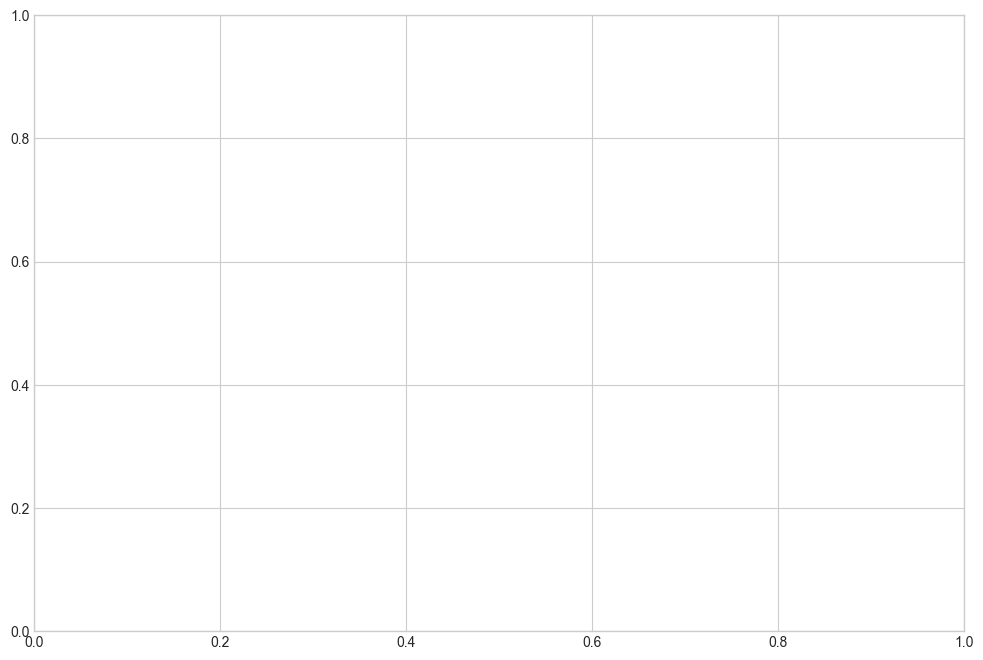

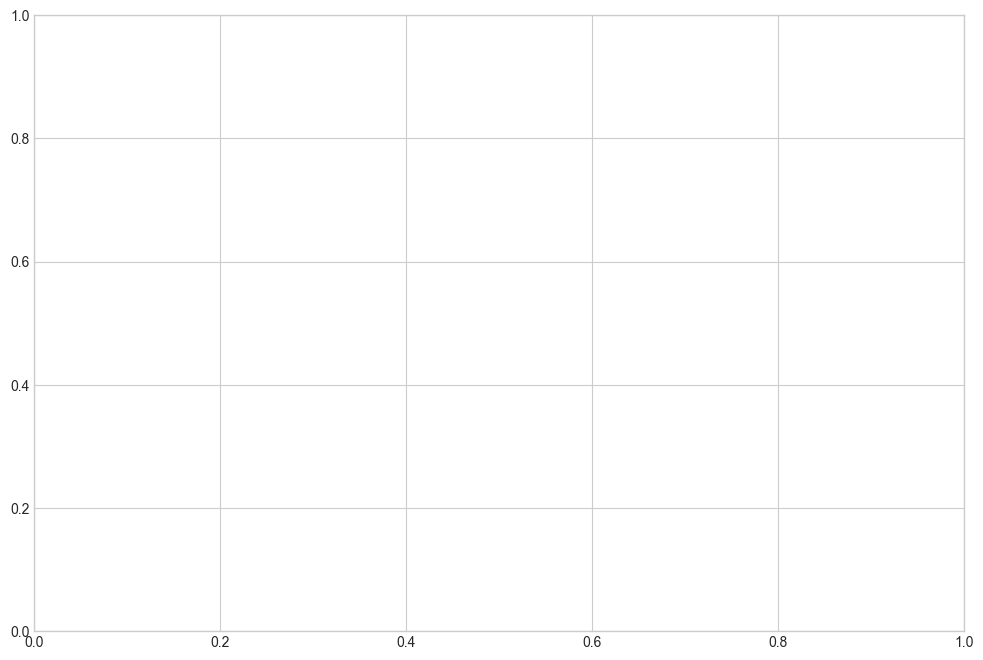

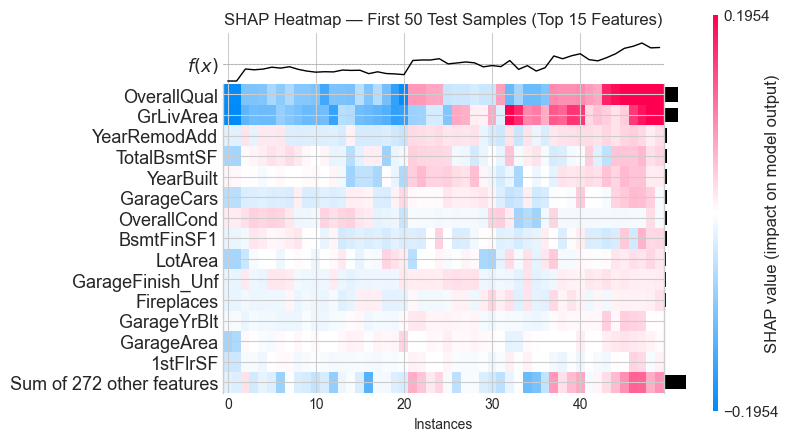

In [21]:
shap_values_reg.feature_names = feature_names_reg

fig, ax = plt.subplots(figsize=(12, 8))
shap.plots.heatmap(
    shap_values_reg[:50],
    max_display=15,
    show=False
)
plt.title("SHAP Heatmap — First 50 Test Samples (Top 15 Features)")
plt.tight_layout()
plt.show()

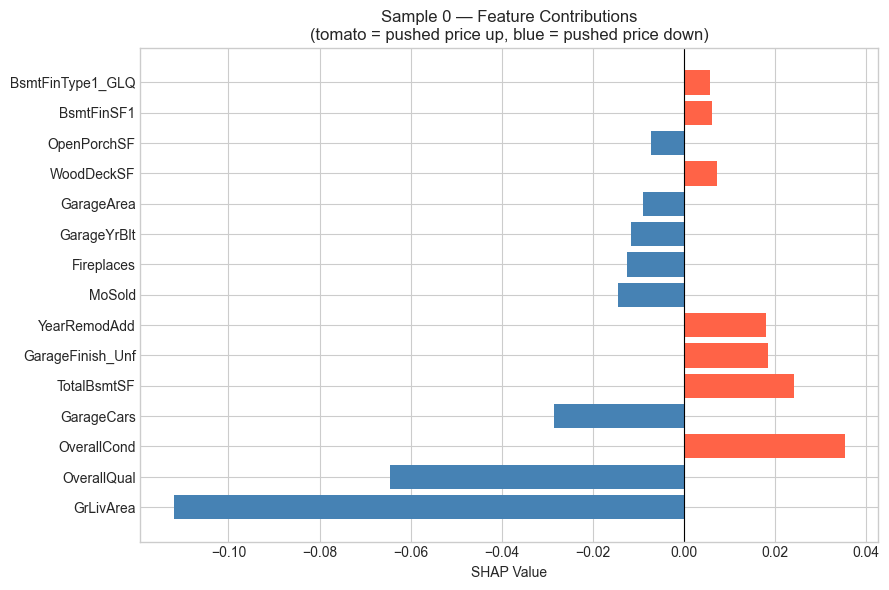

In [22]:
sample_shap_df = pd.DataFrame({
    "feature":    feature_names_reg,
    "shap_value": shap_values_reg.values[sample_idx],
    "feature_value": X_test_reg_processed[sample_idx],
}).reindex(
    pd.Series(shap_values_reg.values[sample_idx]).abs()
    .sort_values(ascending=False).index
).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
colors  = [
    "tomato" if v > 0 else "steelblue"
    for v in sample_shap_df["shap_value"]
]
ax.barh(
    sample_shap_df["feature"],
    sample_shap_df["shap_value"],
    color=colors
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("SHAP Value")
ax.set_title(
    f"Sample {sample_idx} — Feature Contributions\n"
    f"(tomato = pushed price up, blue = pushed price down)"
)
plt.tight_layout()
plt.show()

**Observations**

- The waterfall plot makes the prediction fully transparent — the base value
  plus the sum of all SHAP values equals the exact predicted value. There is
  no approximation
- High and low price predictions are driven by different feature combinations —
  the highest predicted house has large positive SHAP values for quality and
  area features simultaneously, while the lowest has large negative values
  across most features
- The worst prediction often has conflicting SHAP values — some features
  pushing the prediction up and others pushing it down in unusually large
  magnitudes. This suggests the sample has an unusual combination of feature
  values that the model has not seen frequently in training
- The heatmap reveals column-wise patterns — some features have consistent
  colour across all 50 samples (consistent effect) while others alternate
  between red and blue (context-dependent effect)

## SHAP Feature Interactions

Feature interactions occur when the effect of one feature on the prediction
depends on the value of another feature. A single feature's SHAP value
captures its total contribution including interactions — but SHAP interaction
values decompose this further into the pure main effect and the interaction
component with every other feature.

Two tools are used here:
- **Dependence plots** — show how a feature's SHAP value changes across its
  value range, coloured by a second feature to reveal interactions
- **SHAP interaction values** — the full pairwise interaction matrix showing
  which feature pairs have the strongest joint effects

### Dependence Plot

A dependence plot shows the relationship between a feature's value (x-axis)
and its SHAP value (y-axis). A linear relationship means the feature has a
consistent additive effect. A curved or scattered relationship means the
effect is non-linear or context-dependent.

The colour dimension reveals interactions — if points of the same colour
cluster together vertically, the coloured feature is interacting with the
plotted feature.

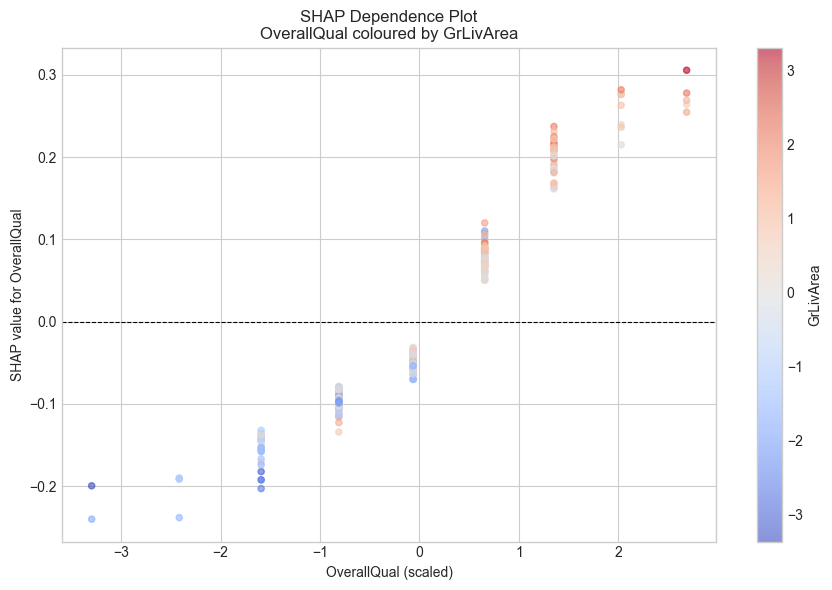

In [23]:
top_feature      = shap_importance.iloc[0]["feature"]
second_feature   = shap_importance.iloc[1]["feature"]

top_idx    = feature_names_reg.index(top_feature)
second_idx = feature_names_reg.index(second_feature)

fig, ax = plt.subplots(figsize=(9, 6))

sc = ax.scatter(
    X_test_reg_processed[:, top_idx],
    shap_values_reg.values[:, top_idx],
    c=X_test_reg_processed[:, second_idx],
    cmap="coolwarm",
    alpha=0.6, s=20
)

plt.colorbar(sc, ax=ax, label=second_feature)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel(f"{top_feature} (scaled)")
ax.set_ylabel(f"SHAP value for {top_feature}")
ax.set_title(f"SHAP Dependence Plot\n{top_feature} coloured by {second_feature}")
plt.tight_layout()
plt.show()

### SHAP Interaction Values

SHAP interaction values decompose each feature's SHAP value into a main
effect (the feature acting alone) and interaction effects (the feature
acting jointly with each other feature). The diagonal of the interaction
matrix contains the main effects. Off-diagonal values are the pairwise
interactions.

Computing full interaction values is expensive — using a subset of the
test set here.

In [24]:
n_interaction_samples = 100

interaction_explainer = shap.TreeExplainer(xgb_reg)
shap_interaction_vals = interaction_explainer.shap_interaction_values(
    X_test_reg_processed[:n_interaction_samples]
)

print(f"Interaction values shape: {shap_interaction_vals.shape}")
print(f"  samples x features x features = "
      f"{n_interaction_samples} x {len(feature_names_reg)} x {len(feature_names_reg)}")

Interaction values shape: (100, 286, 286)
  samples x features x features = 100 x 286 x 286


In [25]:
mean_interactions = np.abs(shap_interaction_vals).mean(axis=0)
np.fill_diagonal(mean_interactions, 0)

interaction_df = pd.DataFrame(
    mean_interactions,
    index=feature_names_reg,
    columns=feature_names_reg
)

interaction_stack = (
    interaction_df
    .stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1",
                     "level_1": "feature_2",
                     0:         "interaction"})
)

interaction_stack = interaction_stack[
    interaction_stack["feature_1"] < interaction_stack["feature_2"]
].sort_values("interaction", ascending=False)

print("Top 15 pairwise feature interactions:")
print(interaction_stack.head(15).round(4).to_string(index=False))

Top 15 pairwise feature interactions:
       feature_1      feature_2  interaction
       GrLivArea    OverallQual       0.0096
       GrLivArea      YearBuilt       0.0043
      GarageCars    OverallQual       0.0035
       GrLivArea    TotalBsmtSF       0.0033
      BsmtFinSF1    OverallQual       0.0031
      GarageCars      GrLivArea       0.0031
      Fireplaces    OverallQual       0.0028
        1stFlrSF      GrLivArea       0.0026
     OverallQual    TotalBsmtSF       0.0026
        1stFlrSF    OverallQual       0.0025
      GarageArea    OverallQual       0.0023
       GrLivArea KitchenQual_TA       0.0021
GarageFinish_Unf      GrLivArea       0.0021
      BsmtFinSF1      GrLivArea       0.0020
GarageFinish_Unf    OverallQual       0.0020


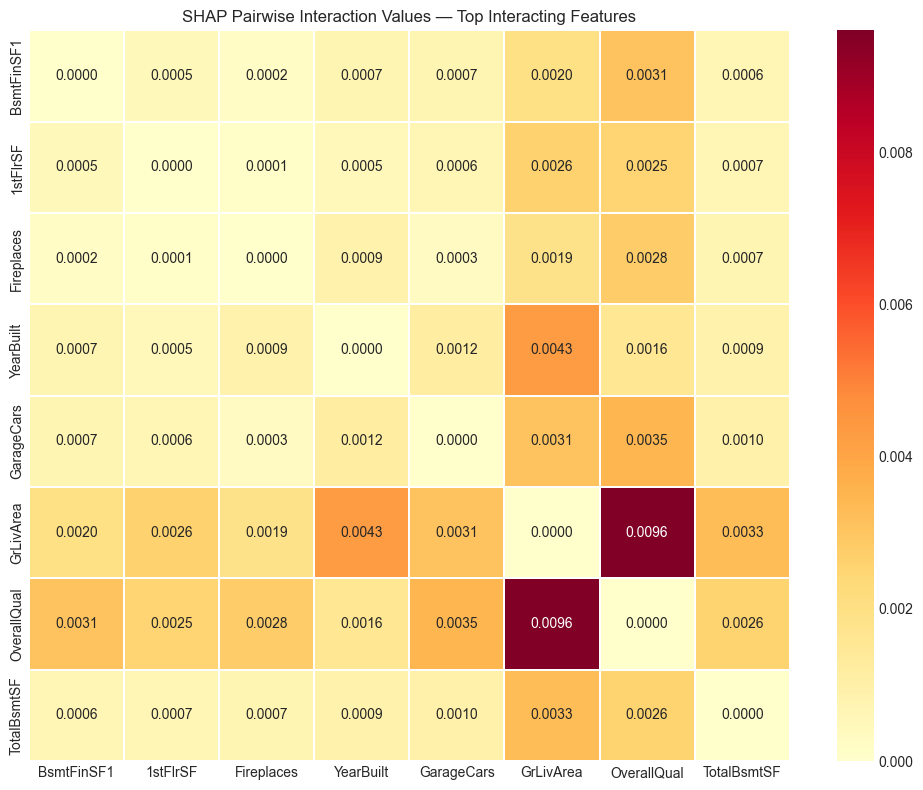

In [26]:
top_interaction_features = list(set(
    interaction_stack.head(10)["feature_1"].tolist() +
    interaction_stack.head(10)["feature_2"].tolist()
))[:10]

top_int_idx = [feature_names_reg.index(f)
               for f in top_interaction_features]

interaction_subset = interaction_df.loc[
    top_interaction_features,
    top_interaction_features
]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    interaction_subset,
    annot=True, fmt=".4f",
    cmap="YlOrRd",
    linewidths=0.3,
    ax=ax
)
ax.set_title("SHAP Pairwise Interaction Values — Top Interacting Features")
plt.tight_layout()
plt.show()

### Main Effect vs Interaction Effect

For the top feature, comparing its main SHAP effect (diagonal) against its
total SHAP value shows how much of its contribution comes from interactions
with other features vs its independent effect.

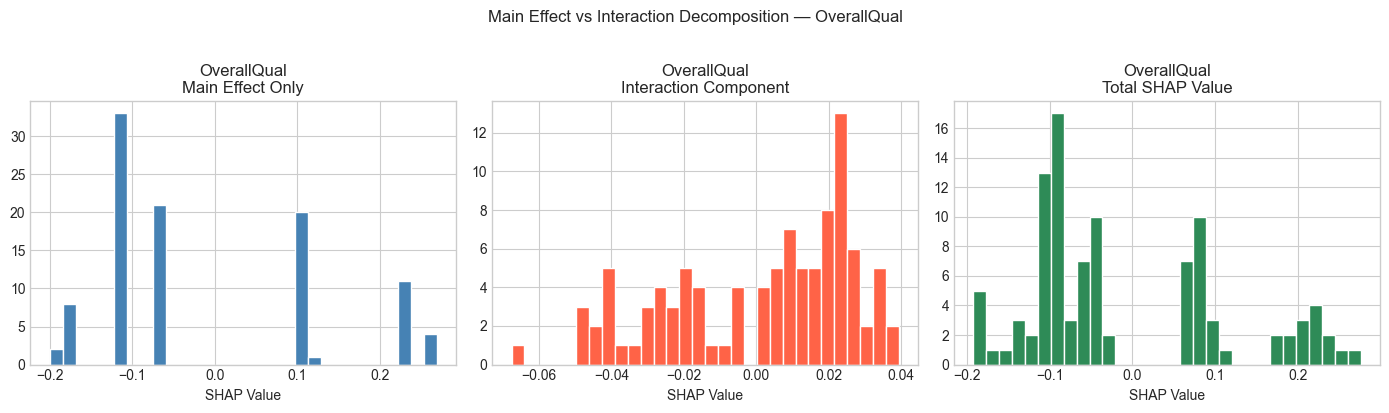

Mean absolute main effect:        0.1294
Mean absolute interaction effect: 0.0222
Interaction as % of total:        20.5%


In [27]:
top_feat_idx = feature_names_reg.index(top_feature)

main_effects  = shap_interaction_vals[
    :, top_feat_idx, top_feat_idx
]
total_shap    = shap_values_reg.values[
    :n_interaction_samples, top_feat_idx
]
interaction_component = total_shap - main_effects

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(main_effects, bins=30,
             color="steelblue", edgecolor="white")
axes[0].set_title(f"{top_feature}\nMain Effect Only")
axes[0].set_xlabel("SHAP Value")

axes[1].hist(interaction_component, bins=30,
             color="tomato", edgecolor="white")
axes[1].set_title(f"{top_feature}\nInteraction Component")
axes[1].set_xlabel("SHAP Value")

axes[2].hist(total_shap, bins=30,
             color="seagreen", edgecolor="white")
axes[2].set_title(f"{top_feature}\nTotal SHAP Value")
axes[2].set_xlabel("SHAP Value")

plt.suptitle(
    f"Main Effect vs Interaction Decomposition — {top_feature}",
    y=1.02
)
plt.tight_layout()
plt.show()

print(f"Mean absolute main effect:        "
      f"{np.abs(main_effects).mean():.4f}")
print(f"Mean absolute interaction effect: "
      f"{np.abs(interaction_component).mean():.4f}")
print(f"Interaction as % of total:        "
      f"{np.abs(interaction_component).mean() / np.abs(total_shap).mean() * 100:.1f}%")

**Observations**

- Dependence plots reveal non-linear relationships that a coefficient alone
  cannot capture — the SHAP value for most top features is not a straight
  line across its value range, confirming the model has learned complex
  non-linear patterns
- The colour dimension in dependence plots makes interactions visible —
  when points of the same colour cluster vertically, the coloured feature
  is modifying the effect of the plotted feature. This is the interaction
  effect made visual
- The interaction heatmap shows that the strongest pairwise interactions
  involve the top globally important features — features that matter globally
  also tend to interact most strongly with each other
- The main effect vs interaction decomposition quantifies how much of a
  feature's total contribution comes from interactions — a high interaction
  percentage means the feature's effect depends heavily on the context
  provided by other features and cannot be understood in isolation
- Interaction values are expensive to compute — for large datasets use a
  representative sample of 100-500 rows rather than the full test set

## LIME — Local Interpretation

LIME (Local Interpretable Model-agnostic Explanations) explains individual
predictions by building a simple interpretable model (linear regression)
in the local neighbourhood of the sample being explained.

    1. Take the sample to explain
    2. Generate perturbed versions of it by randomly turning features on and off
    3. Get predictions from the black box model for all perturbed samples
    4. Weight perturbed samples by their similarity to the original
    5. Fit a weighted linear regression on the perturbed samples
    6. The linear coefficients are the explanation

Key properties:
- Model-agnostic — works on any model that produces predictions
- Local fidelity — the linear approximation is only valid near the explained
  sample, not globally
- Approximate — unlike SHAP, LIME explanations are not mathematically exact.
  Different runs can produce slightly different explanations due to random
  perturbation sampling

Key difference from SHAP:
| Property | SHAP | LIME |
|---|---|---|
| Exactness | Exact Shapley values | Approximation via local linear model |
| Speed | Fast with TreeExplainer | Slower — requires many model calls |
| Consistency | Always consistent | Can vary between runs |
| Global use | Yes | Local only |
| Model-agnostic | Yes | Yes |

In [28]:
lime_explainer_reg = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_reg_processed,
    feature_names=feature_names_reg,
    mode="regression",
    random_state=42,
)

print(f"LIME explainer created.")
print(f"Training data shape: {X_train_reg_processed.shape}")
print(f"Number of features:  {len(feature_names_reg)}")

LIME explainer created.
Training data shape: (1168, 286)
Number of features:  286


In [ ]:
lime_explainer_reg = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_reg_processed,
    feature_names=feature_names_reg,
    mode="regression",
    random_state=42,
)

print(f"LIME explainer created.")
print(f"Training data shape: {X_train_reg_processed.shape}")
print(f"Number of features:  {len(feature_names_reg)}")

In [29]:
sample_idx   = 0
num_features = 15

lime_exp = lime_explainer_reg.explain_instance(
    data_row=X_test_reg_processed[sample_idx],
    predict_fn=xgb_reg.predict,
    num_features=num_features,
)

print(f"Sample {sample_idx}:")
print(f"  Actual:    ${np.expm1(y_test_reg.iloc[sample_idx]):,.0f}")
print(f"  Predicted: ${np.expm1(y_pred_reg[sample_idx]):,.0f}")
print(f"  LIME intercept: {lime_exp.intercept[1] if hasattr(lime_exp.intercept, '__getitem__') else lime_exp.intercept:.4f}")
print(f"\nLIME feature contributions (top {num_features}):")
for feat, weight in lime_exp.as_list():
    direction = "up" if weight > 0 else "down"
    print(f"  {feat:<50} {weight:+.4f}  ({direction})")

Sample 0:
  Actual:    $154,500
  Predicted: $143,000
  LIME intercept: 12.1630

LIME feature contributions (top 15):
  GrLivArea <= -0.71                                 -0.1904  (down)
  Condition2_Artery <= 0.00                          +0.1400  (up)
  Exterior1st_ImStucc <= 0.00                        -0.1346  (down)
  Condition1_RRNe <= 0.00                            -0.1290  (down)
  Neighborhood_Blueste <= 0.00                       -0.1233  (down)
  Exterior2nd_CBlock <= 0.00                         +0.1132  (up)
  Exterior2nd_Stone <= 0.00                          -0.1112  (down)
  PoolQC_Fa <= 0.00                                  -0.1109  (down)
  GarageQual_Po <= 0.00                              +0.0903  (up)
  Condition2_PosA <= 0.00                            -0.0744  (down)
  Condition2_RRAn <= 0.00                            +0.0734  (up)
  GarageCars <= -1.08                                -0.0652  (down)
  Heating_Grav <= 0.00                               +0.0566  

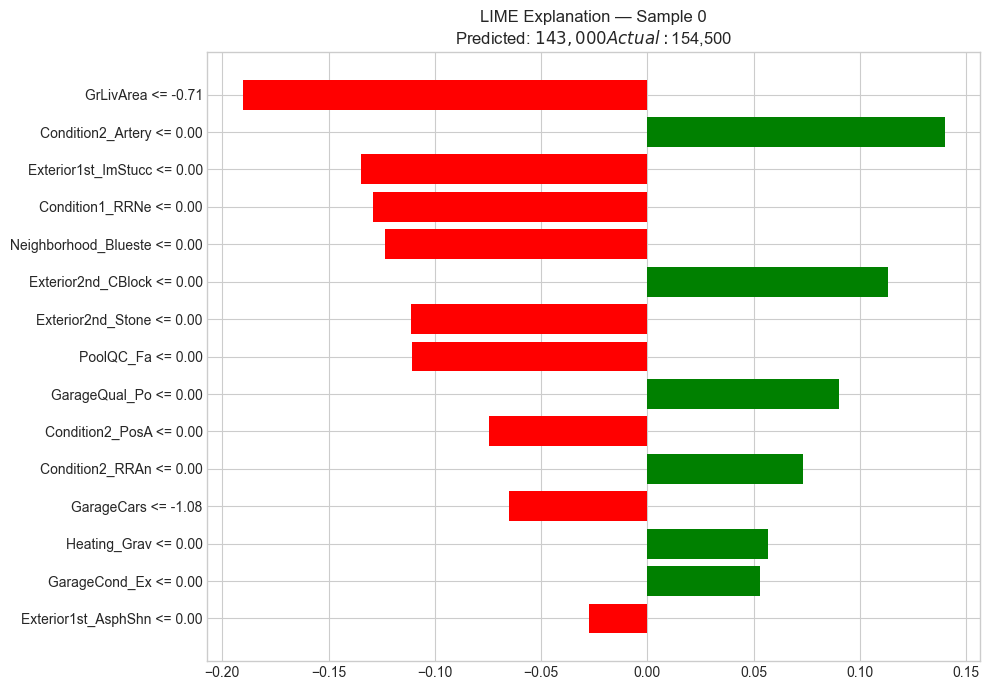

In [30]:
fig = lime_exp.as_pyplot_figure()
fig.set_size_inches(10, 7)
plt.title(
    f"LIME Explanation — Sample {sample_idx}\n"
    f"Predicted: ${np.expm1(y_pred_reg[sample_idx]):,.0f}  "
    f"Actual: ${np.expm1(y_test_reg.iloc[sample_idx]):,.0f}"
)
plt.tight_layout()
plt.show()

### LIME vs SHAP — Same Sample

Both methods explain the same prediction but arrive there differently.
SHAP computes exact Shapley values by considering all feature subsets.
LIME fits a local linear model on perturbed samples. Comparing their
top features and directions shows where they agree and where they diverge.

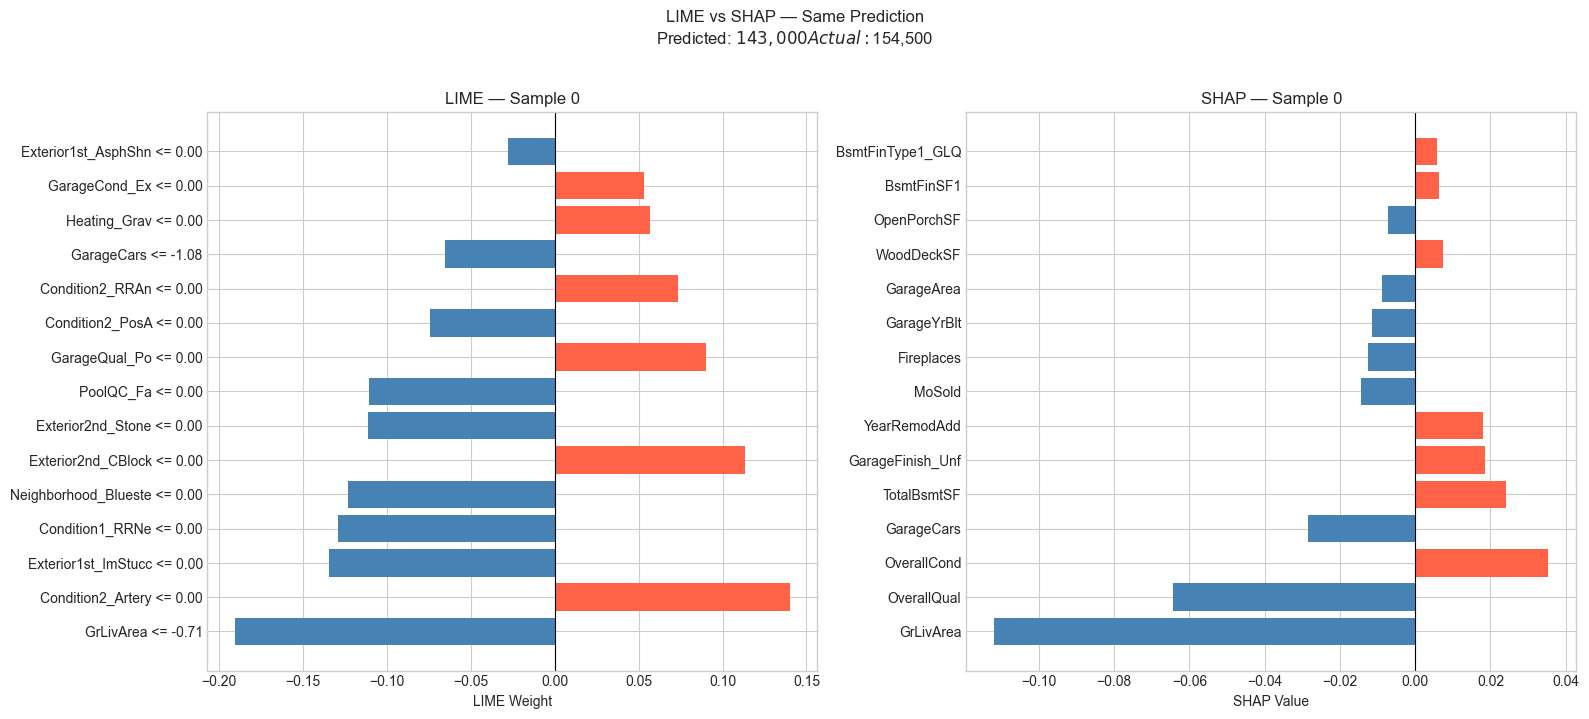

In [31]:
lime_features = pd.DataFrame(
    lime_exp.as_list(),
    columns=["feature_condition", "lime_weight"]
).assign(abs_weight=lambda x: x["lime_weight"].abs())
lime_features = lime_features.sort_values("abs_weight", ascending=False)

shap_sample = pd.DataFrame({
    "feature":    feature_names_reg,
    "shap_value": shap_values_reg.values[sample_idx],
}).assign(abs_shap=lambda x: x["shap_value"].abs())
shap_sample = shap_sample.sort_values("abs_shap", ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors_lime = [
    "tomato" if w > 0 else "steelblue"
    for w in lime_features["lime_weight"]
]
axes[0].barh(
    lime_features["feature_condition"],
    lime_features["lime_weight"],
    color=colors_lime
)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title(f"LIME — Sample {sample_idx}")
axes[0].set_xlabel("LIME Weight")

colors_shap = [
    "tomato" if v > 0 else "steelblue"
    for v in shap_sample["shap_value"]
]
axes[1].barh(
    shap_sample["feature"],
    shap_sample["shap_value"],
    color=colors_shap
)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title(f"SHAP — Sample {sample_idx}")
axes[1].set_xlabel("SHAP Value")

plt.suptitle(
    f"LIME vs SHAP — Same Prediction\n"
    f"Predicted: ${np.expm1(y_pred_reg[sample_idx]):,.0f}  "
    f"Actual: ${np.expm1(y_test_reg.iloc[sample_idx]):,.0f}",
    y=1.02
)
plt.tight_layout()
plt.show()

### LIME Stability

LIME uses random perturbation sampling — different random seeds produce
slightly different explanations for the same sample. Checking stability
across multiple runs quantifies how much the explanation varies.
A stable explanation has consistent feature rankings across seeds.

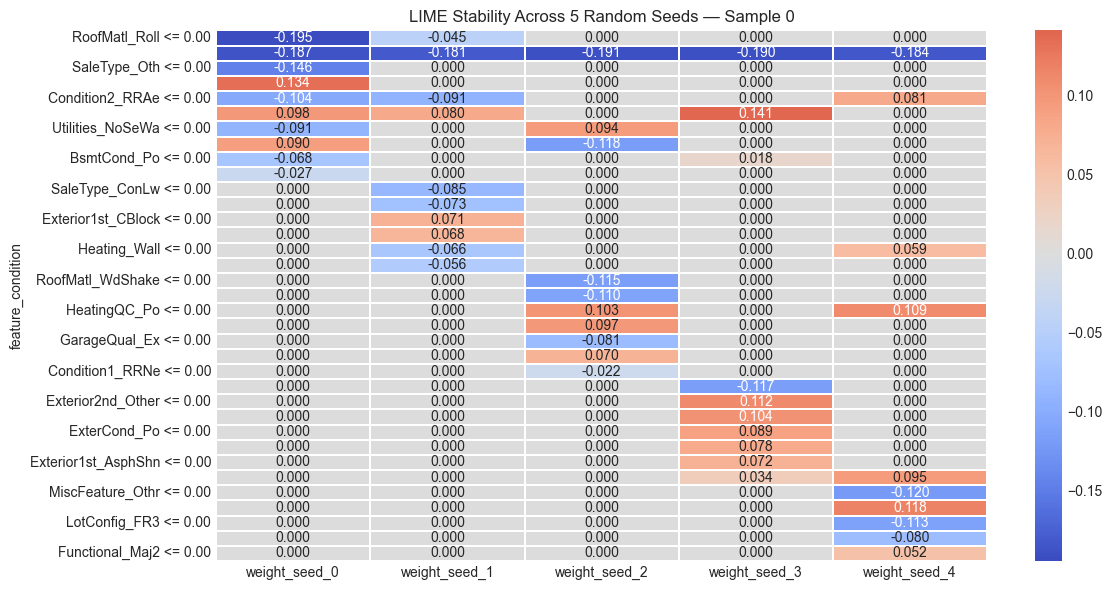

Feature weight std across seeds (higher = less stable):
feature_condition
RoofMatl_Roll <= 0.00          0.0843
Condition2_RRAe <= 0.00        0.0762
Condition2_Artery <= 0.00      0.0739
SaleType_Oth <= 0.00           0.0655
Utilities_NoSeWa <= 0.00       0.0654
MiscFeature_TenC <= 0.00       0.0624
Exterior1st_Stone <= 0.00      0.0601
HeatingQC_Po <= 0.00           0.0582
MiscFeature_Othr <= 0.00       0.0536
RoofMatl_Metal <= 0.00         0.0526
Heating_Floor <= 0.00          0.0523
RoofMatl_WdShake <= 0.00       0.0514
LotConfig_FR3 <= 0.00          0.0504
Exterior2nd_Other <= 0.00      0.0500
Functional_Sev <= 0.00         0.0494
Condition2_RRNn <= 0.00        0.0463
Heating_Wall <= 0.00           0.0443
Condition2_PosA <= 0.00        0.0435
RoofMatl_ClyTile <= 0.00       0.0414
ExterCond_Po <= 0.00           0.0397
SaleType_ConLw <= 0.00         0.0380
GarageQual_Ex <= 0.00          0.0360
PoolQC_Fa <= 0.00              0.0359
Exterior2nd_CBlock <= 0.00     0.0351
BsmtCond_Po <=

In [34]:
n_runs       = 5
lime_runs    = []

for seed in range(n_runs):
    explainer_run = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train_reg_processed,
        feature_names=feature_names_reg,
        mode="regression",
        random_state=seed,
    )
    exp_run = explainer_run.explain_instance(
        data_row=X_test_reg_processed[sample_idx],
        predict_fn=xgb_reg.predict,
        num_features=10,
    )
    run_df = pd.DataFrame(
        exp_run.as_list(),
        columns=["feature_condition", f"weight_seed_{seed}"]
    ).set_index("feature_condition")
    lime_runs.append(run_df)

stability_df = pd.concat(lime_runs, axis=1).fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    stability_df,
    annot=True, fmt=".3f",
    cmap="coolwarm", center=0,
    linewidths=0.3,
    ax=ax
)
ax.set_title(f"LIME Stability Across {n_runs} Random Seeds — Sample {sample_idx}")
plt.tight_layout()
plt.show()

weight_std = stability_df.std(axis=1).sort_values(ascending=False)
print("Feature weight std across seeds (higher = less stable):")
print(weight_std.round(4).to_string())

### LIME Across Multiple Samples

Running LIME on several samples and comparing the top features shows
whether the local explanations are consistent across different houses
or highly sample-specific.

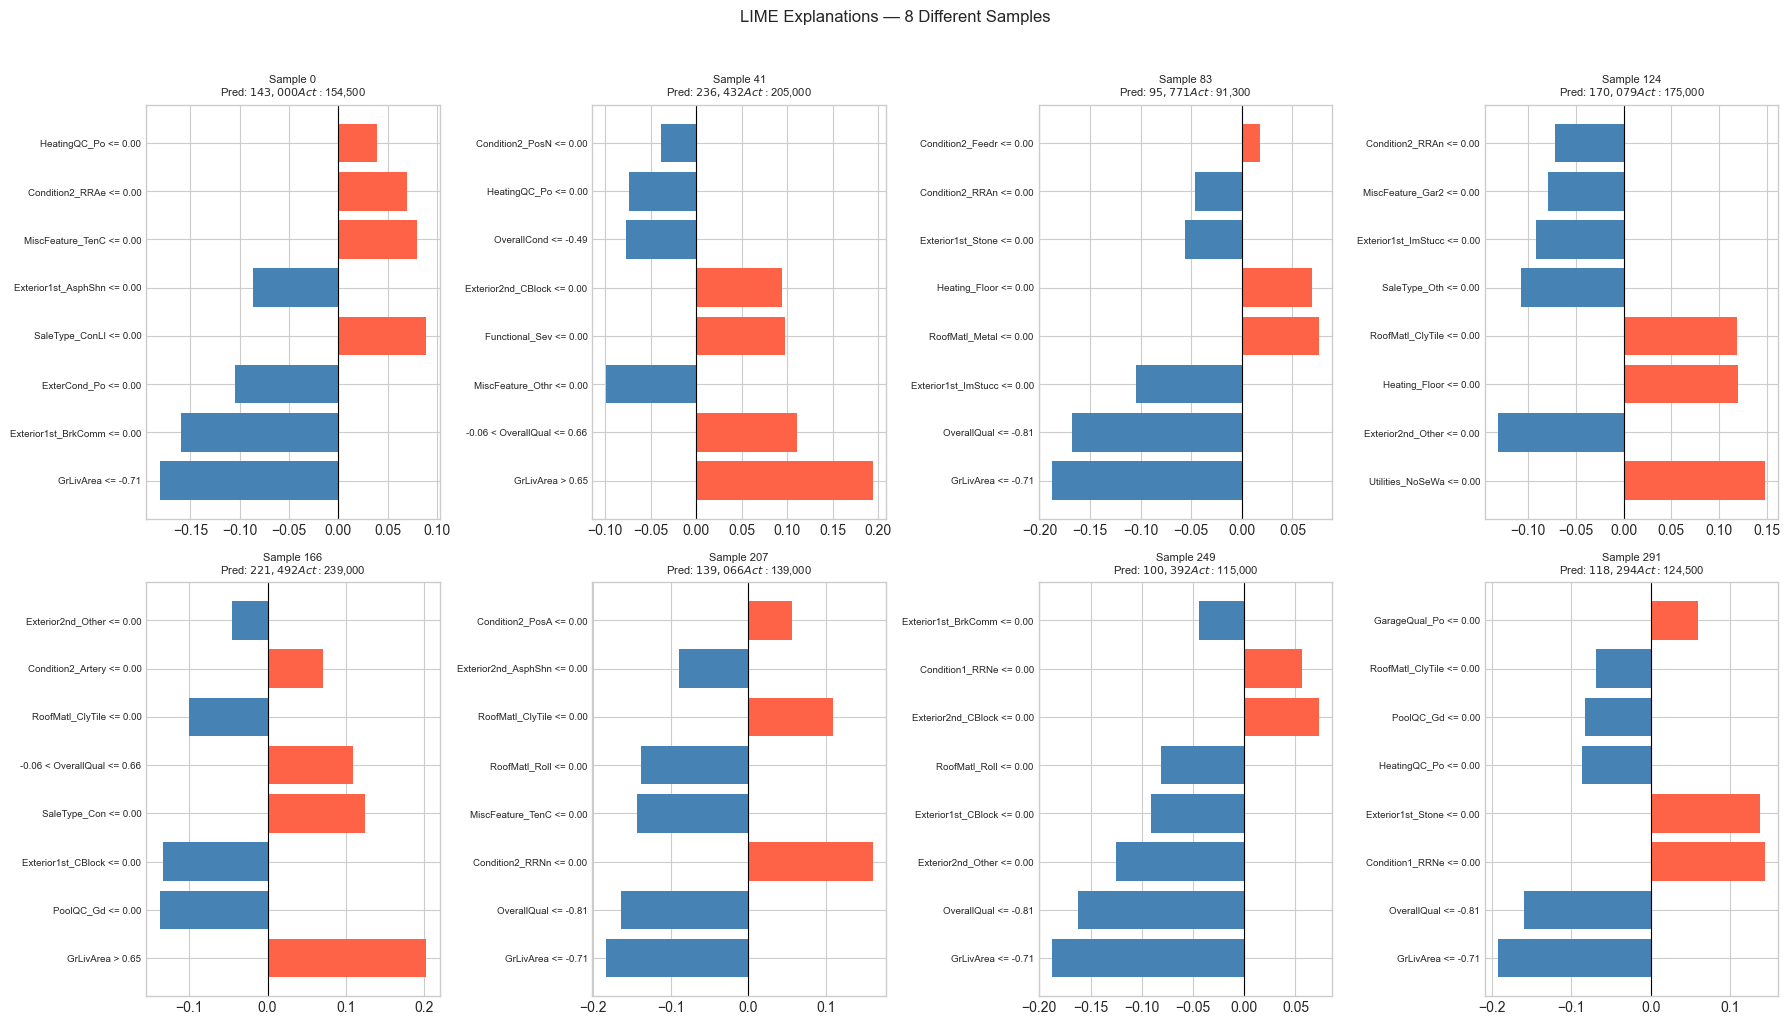

In [35]:
n_samples      = 8
sample_indices = np.linspace(0, len(X_test_reg_processed) - 1,
                              n_samples, dtype=int)

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axis_list  = axes.flatten()

for ax, idx in zip(axis_list, sample_indices):
    exp = lime_explainer_reg.explain_instance(
        data_row=X_test_reg_processed[idx],
        predict_fn=xgb_reg.predict,
        num_features=8,
    )
    features = [f for f, _ in exp.as_list()]
    weights  = [w for _, w in exp.as_list()]
    colors   = ["tomato" if w > 0 else "steelblue" for w in weights]

    ax.barh(features, weights, color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(
        f"Sample {idx}\n"
        f"Pred: ${np.expm1(y_pred_reg[idx]):,.0f}  "
        f"Act: ${np.expm1(y_test_reg.iloc[idx]):,.0f}",
        fontsize=8
    )
    ax.tick_params(axis="y", labelsize=7)

plt.suptitle("LIME Explanations — 8 Different Samples", y=1.02)
plt.tight_layout()
plt.show()

**Observations**

- LIME explanations are readable and intuitive — the feature conditions
  (e.g. "OverallQual > 1.5") directly state what property of the house
  drove the prediction up or down in plain terms
- LIME and SHAP agree on the most important features and their directions
  for most samples — both identify the same top drivers. Where they disagree
  is usually on lower-ranked features with smaller contributions
- LIME stability analysis reveals that lower-ranked features vary more across
  random seeds than top features — the most important drivers are consistently
  identified regardless of the perturbation sample. This is reassuring for
  the top-feature explanation even if the full list shifts
- The multi-sample comparison shows that explanations are sample-specific —
  different houses have different top drivers. A house penalised for low
  quality may be boosted by a large garage, while another is penalised for
  both. Local explanations are not interchangeable across samples
- The key practical difference between LIME and SHAP: SHAP is the default
  for tree models because TreeExplainer is fast and exact. LIME is valuable
  for non-tree models where SHAP has no fast exact implementation

## Interpretation on Classification

Applying SHAP and LIME to the Random Forest classifier on the Breast Cancer
dataset. Classification interpretation answers a different question than
regression — instead of "why did the model predict this price", it answers
"why did the model predict malignant rather than benign for this patient".

SHAP values for classification represent the contribution of each feature
to the log-odds of the predicted class. Positive SHAP pushes toward the
positive class (benign=1), negative SHAP pushes toward malignant (0).

The medical context makes interpretation especially meaningful — knowing
which measurements drive a malignancy prediction is directly actionable
for clinicians.

In [36]:
explainer_clf   = shap.TreeExplainer(rf_clf)
shap_values_clf = explainer_clf(
    X_test_clf_scaled,
    check_additivity=False
)

shap_values_clf.feature_names = feature_names_clf

print(f"SHAP values shape: {shap_values_clf.values.shape}")
print(f"Classes: {cancer.target_names.tolist()}")
print(f"Base value: {explainer_clf.expected_value}")

SHAP values shape: (114, 30, 2)
Classes: ['malignant', 'benign']
Base value: [0.37551648 0.62448352]


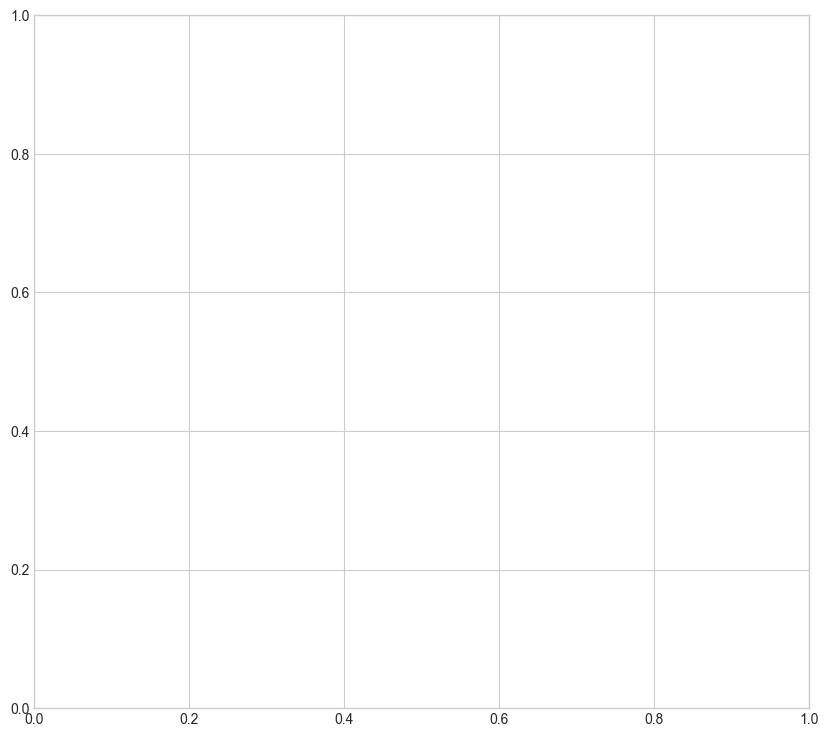

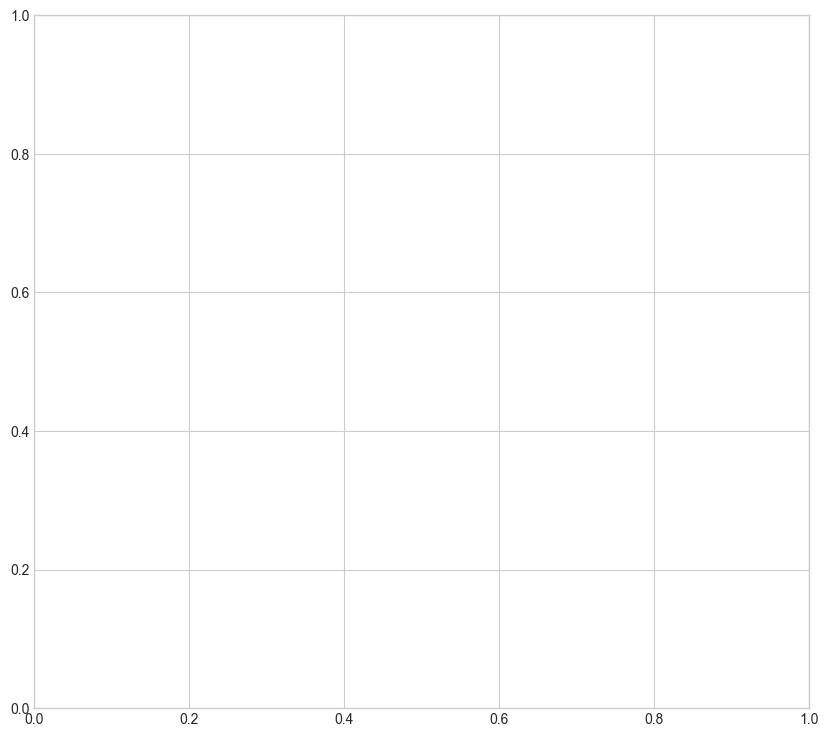

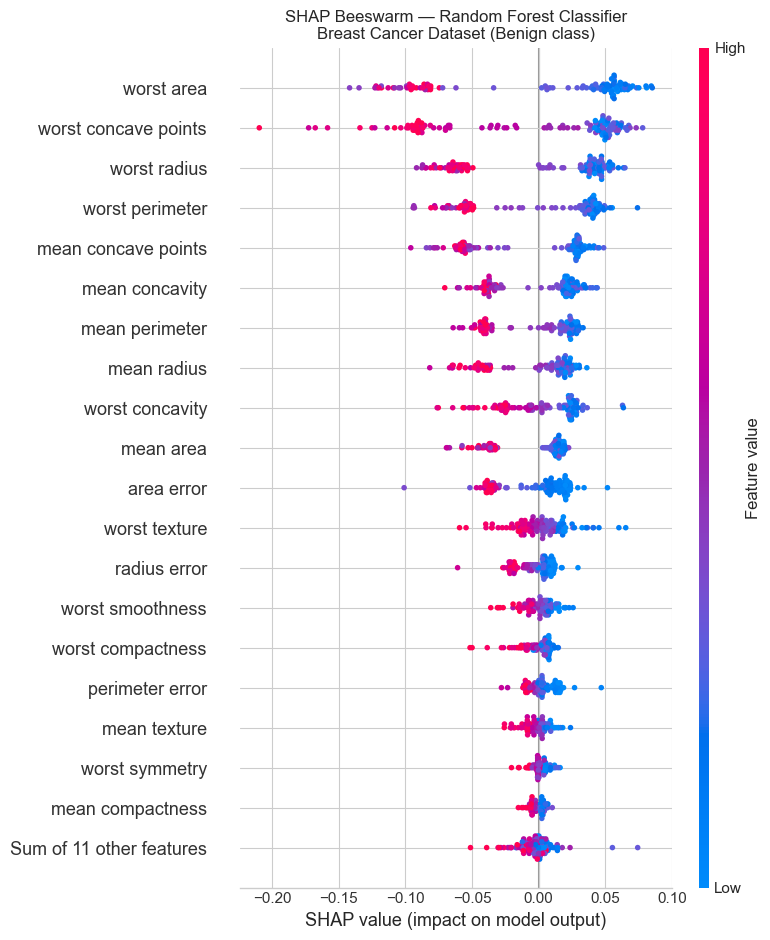

In [39]:
shap_values_clf_class1 = shap_values_clf[..., 1]
shap_values_clf_class1.feature_names = feature_names_clf

fig, ax = plt.subplots(figsize=(10, 9))
shap.plots.beeswarm(shap_values_clf_class1, max_display=20, show=False)
plt.title("SHAP Beeswarm — Random Forest Classifier\nBreast Cancer Dataset (Benign class)")
plt.tight_layout()
plt.show()

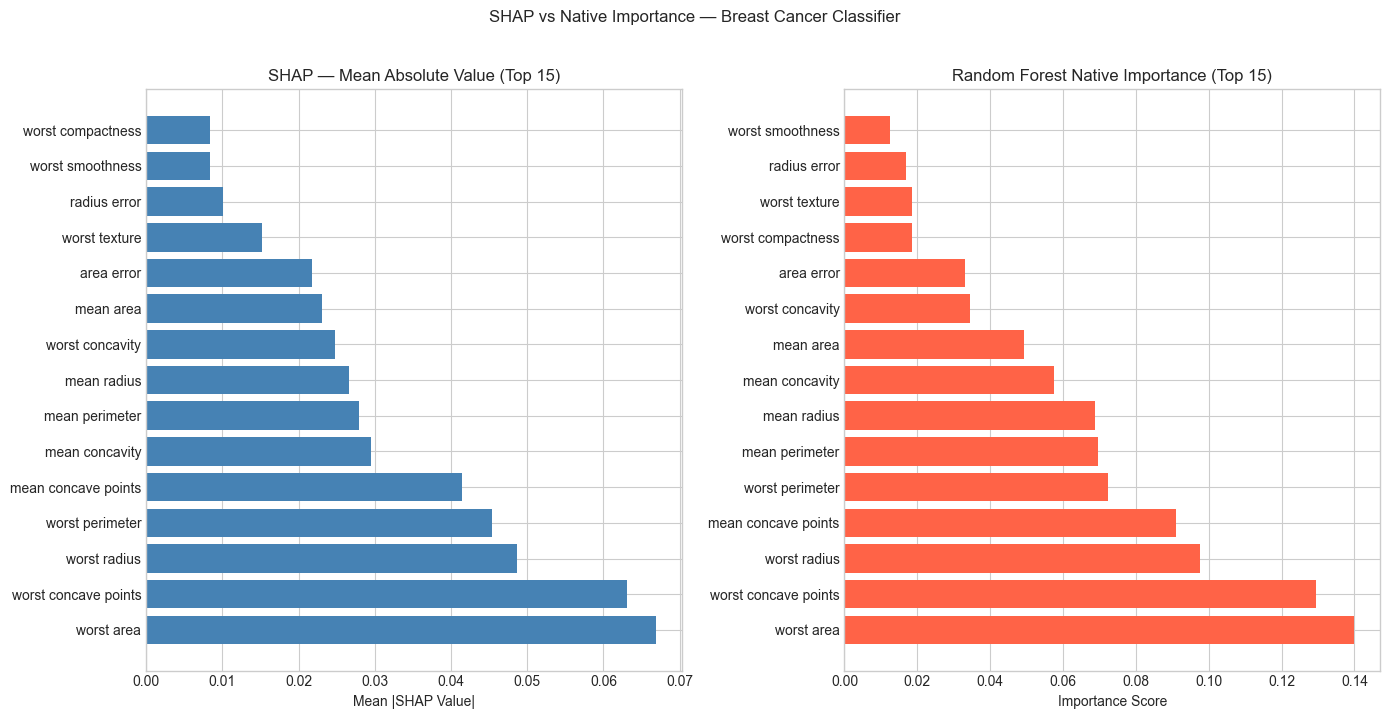

In [41]:
clf_shap_importance = pd.DataFrame({
    "feature":       feature_names_clf,
    "mean_abs_shap": np.abs(shap_values_clf_class1.values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

rf_importance = pd.DataFrame({
    "feature":    feature_names_clf,
    "importance": rf_clf.feature_importances_,
}).sort_values("importance", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].barh(
    clf_shap_importance.head(15)["feature"],
    clf_shap_importance.head(15)["mean_abs_shap"],
    color="steelblue"
)
axes[0].set_title("SHAP — Mean Absolute Value (Top 15)")
axes[0].set_xlabel("Mean |SHAP Value|")

axes[1].barh(
    rf_importance.head(15)["feature"],
    rf_importance.head(15)["importance"],
    color="tomato"
)
axes[1].set_title("Random Forest Native Importance (Top 15)")
axes[1].set_xlabel("Importance Score")

plt.suptitle("SHAP vs Native Importance — Breast Cancer Classifier", y=1.02)
plt.tight_layout()
plt.show()

### Local SHAP — Correct vs Incorrect Classification

Finding one correctly classified and one misclassified sample and comparing
their SHAP waterfall plots. Misclassified samples often have unusual feature
value combinations where the model's learned patterns break down.

In [42]:
correct_mask   = y_pred_clf == y_test_clf.values
incorrect_mask = ~correct_mask

correct_idx   = np.where(correct_mask)[0][0]
incorrect_idx = np.where(incorrect_mask)[0][0] if incorrect_mask.any() else None

print(f"Correct predictions:   {correct_mask.sum()}")
print(f"Incorrect predictions: {incorrect_mask.sum()}")

if incorrect_idx is not None:
    print(f"\nCorrect sample {correct_idx}:")
    print(f"  True label:      {cancer.target_names[y_test_clf.iloc[correct_idx]]}")
    print(f"  Predicted label: {cancer.target_names[y_pred_clf[correct_idx]]}")

    print(f"\nIncorrect sample {incorrect_idx}:")
    print(f"  True label:      {cancer.target_names[y_test_clf.iloc[incorrect_idx]]}")
    print(f"  Predicted label: {cancer.target_names[y_pred_clf[incorrect_idx]]}")

Correct predictions:   109
Incorrect predictions: 5

Correct sample 0:
  True label:      malignant
  Predicted label: malignant

Incorrect sample 3:
  True label:      benign
  Predicted label: malignant


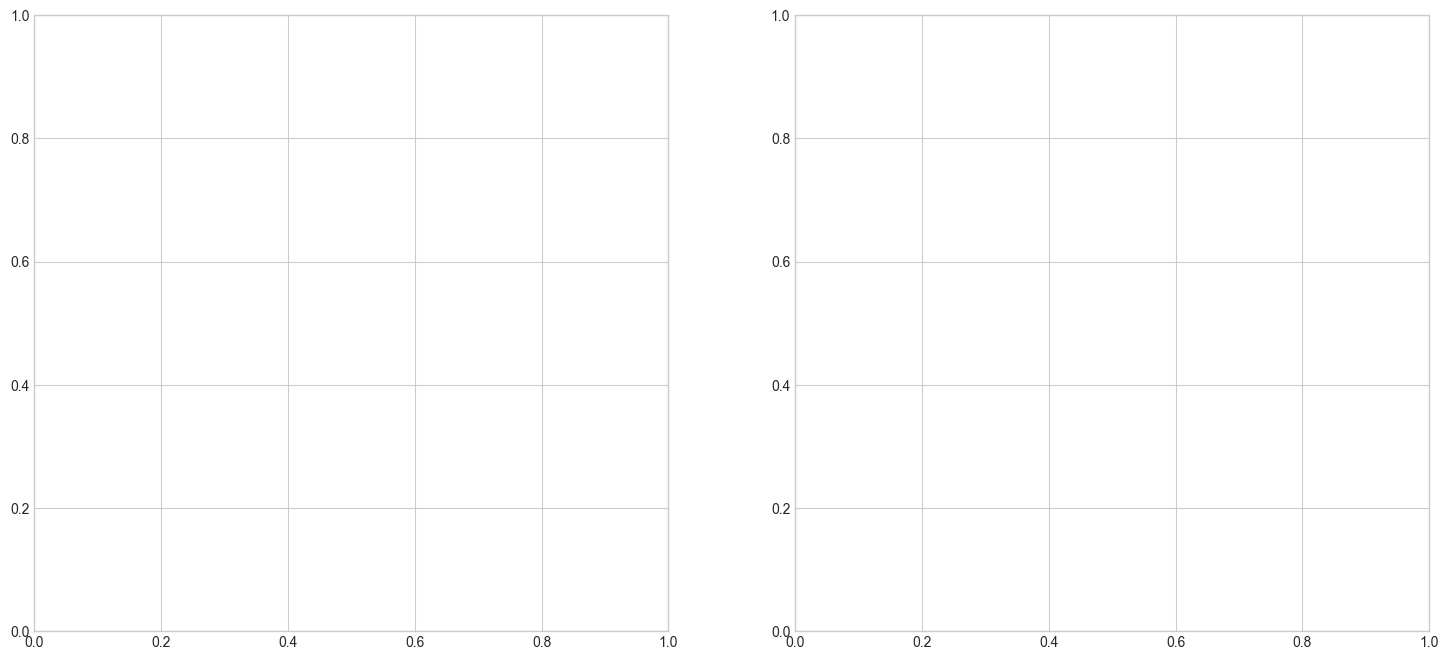

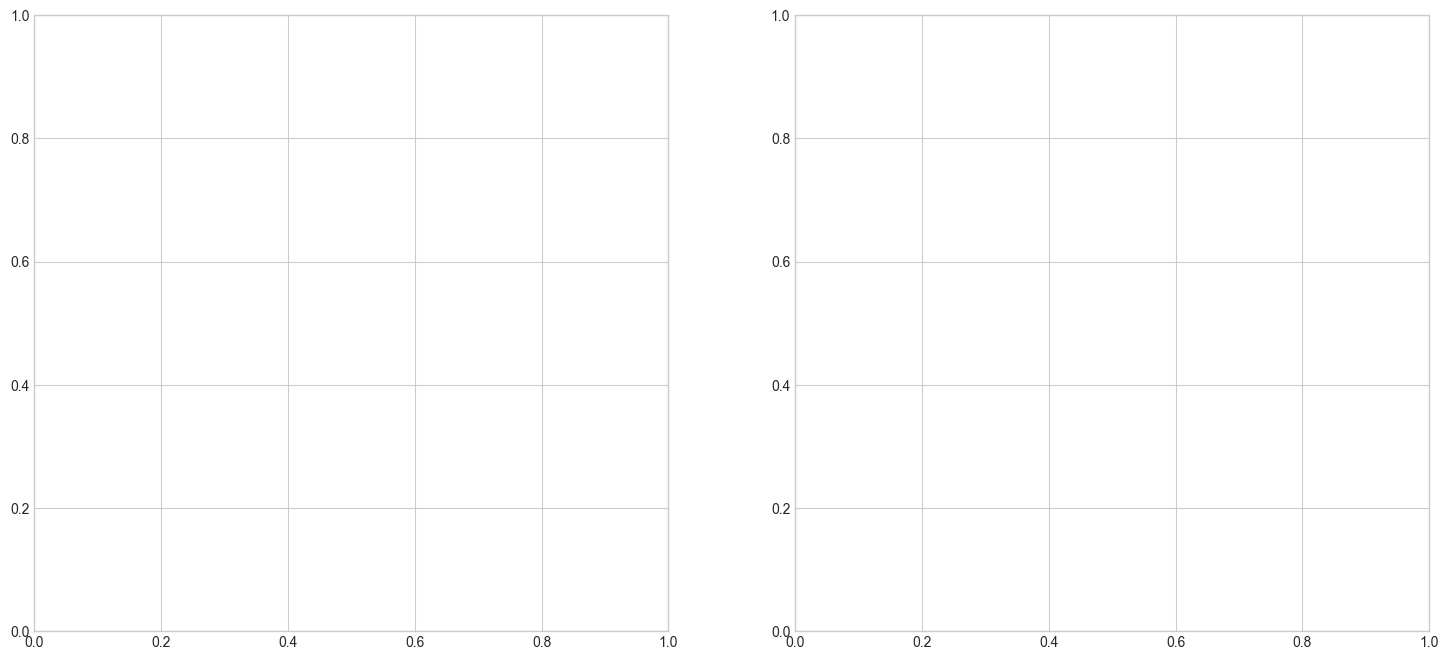

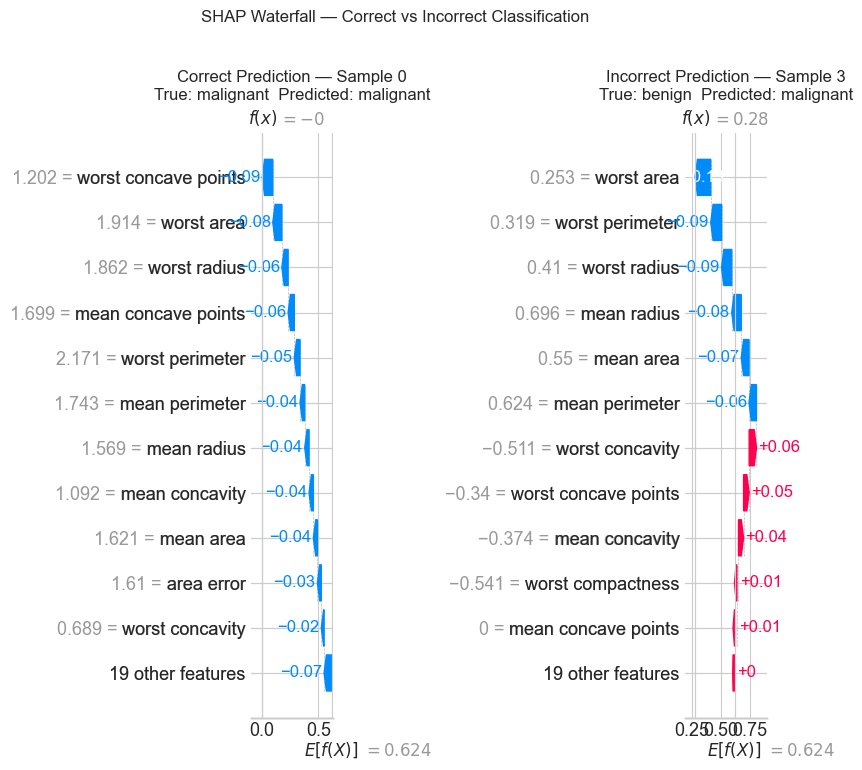

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

plt.sca(axes[0])
shap.plots.waterfall(
    shap_values_clf_class1[correct_idx],
    max_display=12,
    show=False
)
axes[0].set_title(
    f"Correct Prediction — Sample {correct_idx}\n"
    f"True: {cancer.target_names[y_test_clf.iloc[correct_idx]]}  "
    f"Predicted: {cancer.target_names[y_pred_clf[correct_idx]]}"
)

if incorrect_idx is not None:
    plt.sca(axes[1])
    shap.plots.waterfall(
        shap_values_clf_class1[incorrect_idx],
        max_display=12,
        show=False
    )
    axes[1].set_title(
        f"Incorrect Prediction — Sample {incorrect_idx}\n"
        f"True: {cancer.target_names[y_test_clf.iloc[incorrect_idx]]}  "
        f"Predicted: {cancer.target_names[y_pred_clf[incorrect_idx]]}"
    )
else:
    axes[1].text(0.5, 0.5, "No incorrect predictions\non this test set",
                 ha="center", va="center", fontsize=12)
    axes[1].axis("off")

plt.suptitle("SHAP Waterfall — Correct vs Incorrect Classification", y=1.02)
plt.tight_layout()
plt.show()

In [46]:
lime_explainer_clf = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_clf_scaled,
    feature_names=feature_names_clf,
    class_names=cancer.target_names.tolist(),
    mode="classification",
    random_state=42,
)

print("LIME classifier explainer created.")
print(f"Classes: {cancer.target_names.tolist()}")

LIME classifier explainer created.
Classes: ['malignant', 'benign']


### LIME — Malignant Prediction

Finding a sample predicted as malignant and explaining which features
drove that prediction. In a clinical context this explanation would tell
a clinician which measurements were most concerning.

In [47]:
malignant_pred_indices = np.where(y_pred_clf == 0)[0]
malignant_idx          = malignant_pred_indices[0]

lime_clf_exp = lime_explainer_clf.explain_instance(
    data_row=X_test_clf_scaled[malignant_idx],
    predict_fn=rf_clf.predict_proba,
    num_features=12,
)

print(f"Sample {malignant_idx}:")
print(f"  True label:      "
      f"{cancer.target_names[y_test_clf.iloc[malignant_idx]]}")
print(f"  Predicted label: "
      f"{cancer.target_names[y_pred_clf[malignant_idx]]}")
print(f"  Predicted proba: "
      f"{rf_clf.predict_proba(X_test_clf_scaled[[malignant_idx]])[0]}")
print(f"\nLIME explanation:")
for feat, weight in lime_clf_exp.as_list():
    print(f"  {feat:<45} {weight:+.4f}")

Sample 0:
  True label:      malignant
  Predicted label: malignant
  Predicted proba: [1. 0.]

LIME explanation:
  worst concave points > 0.73                   -0.1440
  worst area > 0.30                             -0.1411
  worst radius > 0.50                           -0.1049
  worst perimeter > 0.55                        -0.0804
  mean concave points > 0.66                    -0.0606
  area error > 0.13                             -0.0526
  worst texture > 0.60                          -0.0518
  mean perimeter > 0.50                         -0.0453
  mean radius > 0.48                            -0.0445
  worst concavity > 0.50                        -0.0384
  mean area > 0.35                              -0.0354
  mean concavity > 0.53                         -0.0347


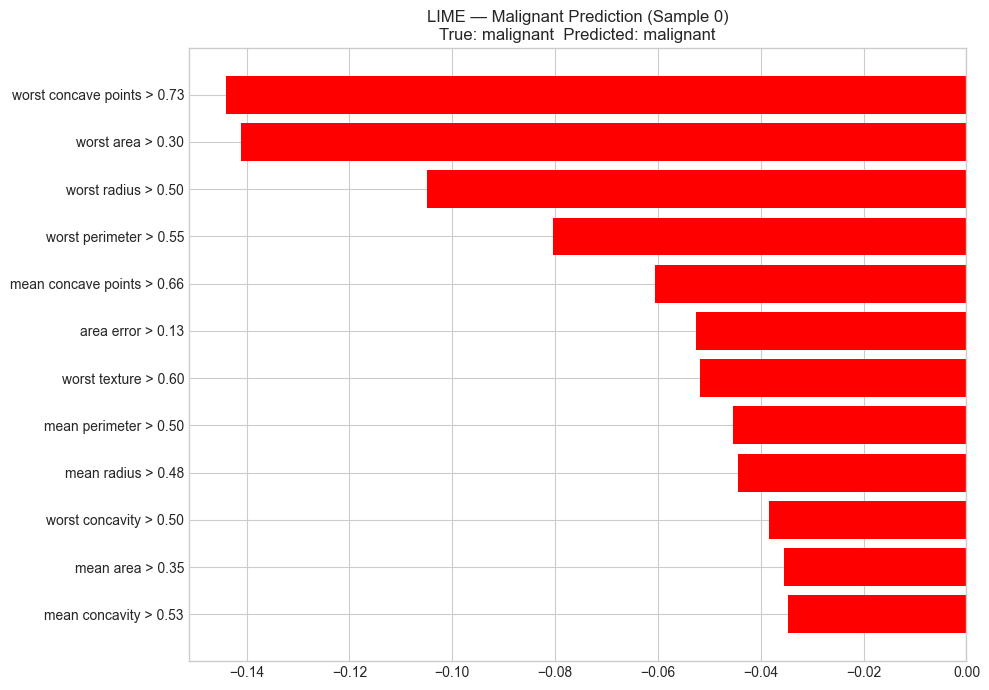

In [48]:
fig = lime_clf_exp.as_pyplot_figure()
fig.set_size_inches(10, 7)
plt.title(
    f"LIME — Malignant Prediction (Sample {malignant_idx})\n"
    f"True: {cancer.target_names[y_test_clf.iloc[malignant_idx]]}  "
    f"Predicted: {cancer.target_names[y_pred_clf[malignant_idx]]}"
)
plt.tight_layout()
plt.show()

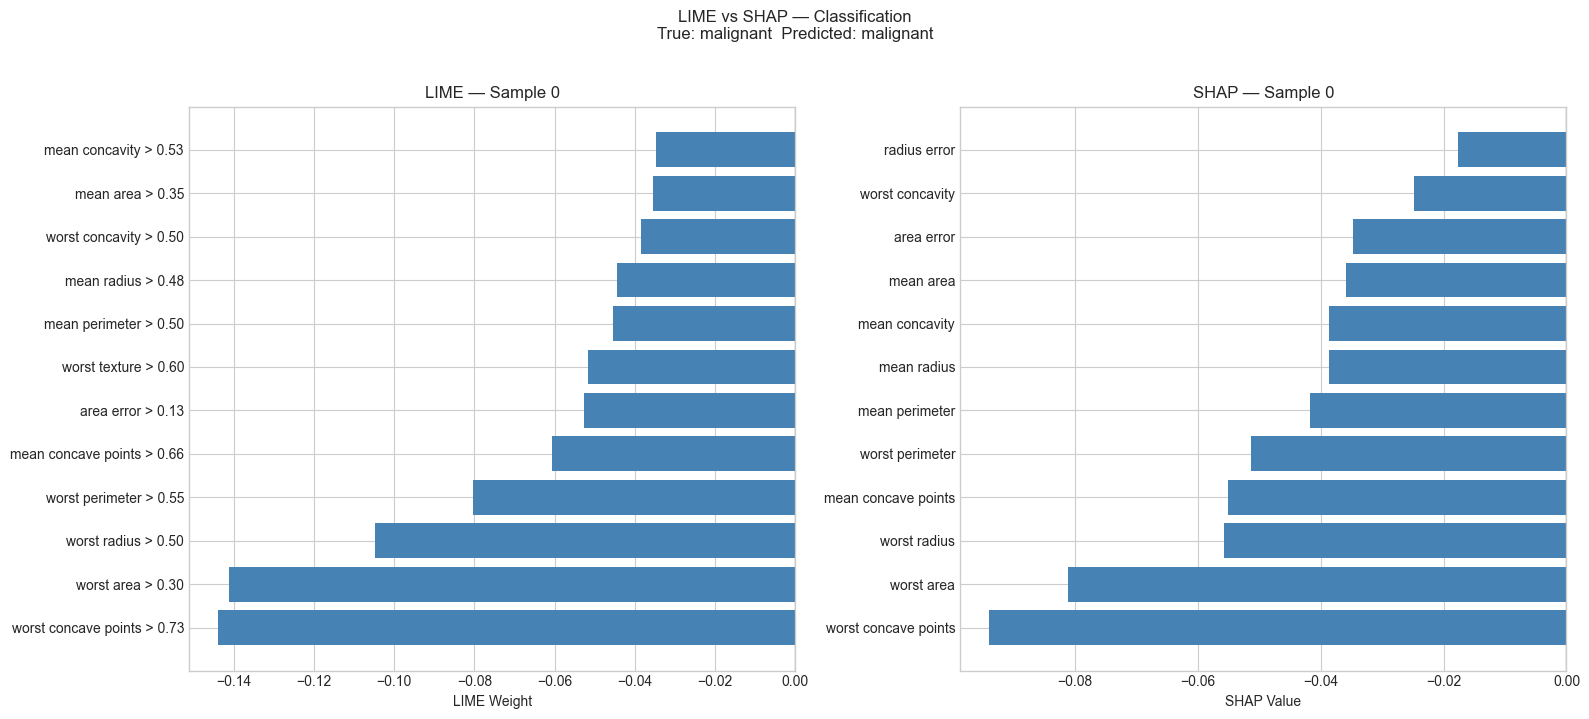

In [50]:
shap_sample_clf = pd.DataFrame({
    "feature":    feature_names_clf,
    "shap_value": shap_values_clf_class1.values[malignant_idx],
}).assign(abs_shap=lambda x: x["shap_value"].abs())
shap_sample_clf = shap_sample_clf.sort_values(
    "abs_shap", ascending=False
).head(12)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors_lime = [
    "tomato" if w > 0 else "steelblue"
    for w in lime_clf_features["lime_weight"]
]
axes[0].barh(
    lime_clf_features["feature_condition"],
    lime_clf_features["lime_weight"],
    color=colors_lime
)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title(f"LIME — Sample {malignant_idx}")
axes[0].set_xlabel("LIME Weight")

colors_shap = [
    "tomato" if v > 0 else "steelblue"
    for v in shap_sample_clf["shap_value"]
]
axes[1].barh(
    shap_sample_clf["feature"],
    shap_sample_clf["shap_value"],
    color=colors_shap
)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title(f"SHAP — Sample {malignant_idx}")
axes[1].set_xlabel("SHAP Value")

plt.suptitle(
    f"LIME vs SHAP — Classification\n"
    f"True: {cancer.target_names[y_test_clf.iloc[malignant_idx]]}  "
    f"Predicted: {cancer.target_names[y_pred_clf[malignant_idx]]}",
    y=1.02
)
plt.tight_layout()
plt.show()

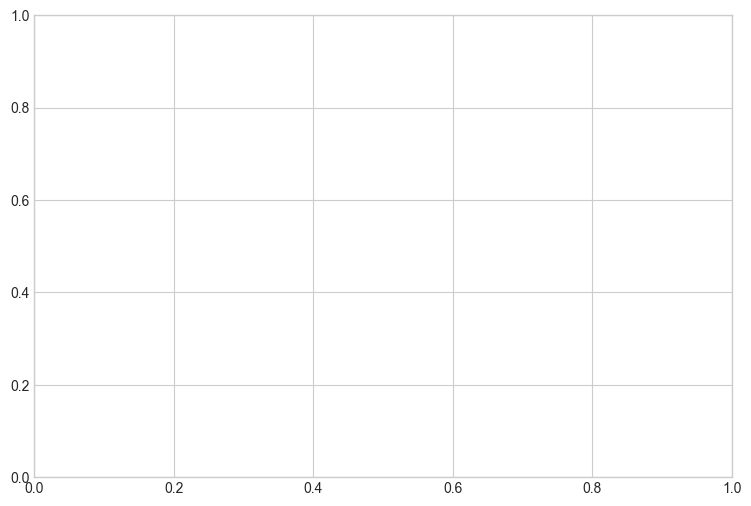

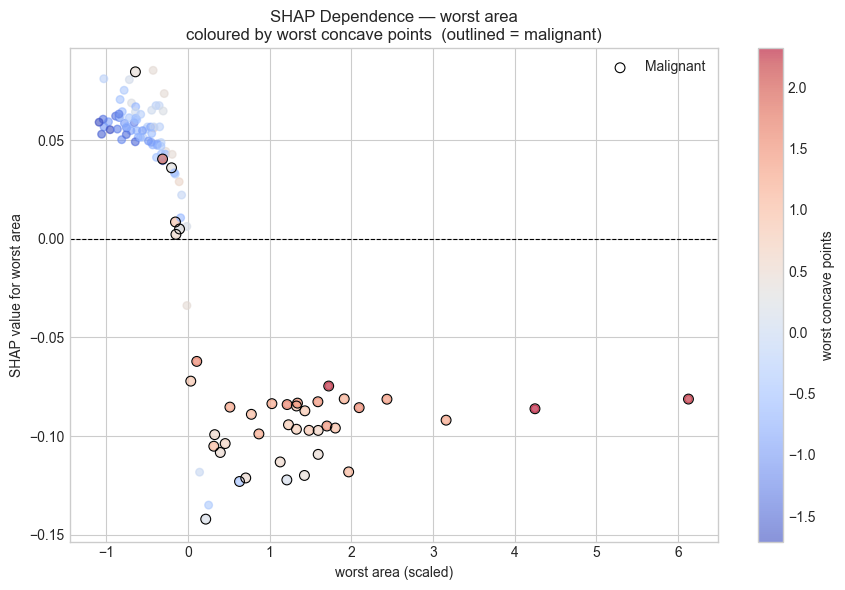

In [52]:
top_clf_feature     = clf_shap_importance.iloc[0]["feature"]
second_clf_feature  = clf_shap_importance.iloc[1]["feature"]

top_clf_idx    = feature_names_clf.index(top_clf_feature)
second_clf_idx = feature_names_clf.index(second_clf_feature)

fig, ax = plt.subplots(figsize=(9, 6))

sc = ax.scatter(
    X_test_clf_scaled[:, top_clf_idx],
    shap_values_clf_class1.values[:, top_clf_idx],
    c=X_test_clf_scaled[:, second_clf_idx],
    cmap="coolwarm",
    alpha=0.6, s=30
)

plt.colorbar(sc, ax=ax, label=second_clf_feature)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

malignant_mask = y_test_clf.values == 0
ax.scatter(
    X_test_clf_scaled[malignant_mask, top_clf_idx],
    shap_values_clf_class1.values[malignant_mask, top_clf_idx],
    edgecolors="black", facecolors="none",
    s=50, linewidth=0.8, label="Malignant"
)

ax.set_xlabel(f"{top_clf_feature} (scaled)")
ax.set_ylabel(f"SHAP value for {top_clf_feature}")
ax.set_title(
    f"SHAP Dependence — {top_clf_feature}\n"
    f"coloured by {second_clf_feature}  "
    f"(outlined = malignant)"
)
ax.legend()
plt.tight_layout()
plt.show()

**Observations**

- SHAP beeswarm on the classifier shows clear directional patterns — high
  values of the top features (worst concave points, worst perimeter) push
  predictions toward malignant (negative SHAP) and low values push toward
  benign (positive SHAP)
- SHAP and native Random Forest importance largely agree on top features
  for this dataset — the clean separability of the Breast Cancer classes
  means both methods identify the same dominant signals
- The malignant prediction explanation from LIME is clinically meaningful —
  it identifies which specific measurements exceeded concerning thresholds.
  A clinician could directly map LIME conditions to abnormal test results
- SHAP and LIME agree on the direction of the top features for the malignant
  prediction but LIME expresses them as threshold conditions while SHAP gives
  continuous contribution magnitudes — LIME is more readable for non-technical
  stakeholders, SHAP is more precise for technical analysis
- The dependence plot with malignant samples outlined shows that malignant
  cases cluster at high feature values with large negative SHAP — confirming
  the model correctly associates high measurements with malignancy

## Key Takeaways

### Why Model Interpretation Matters
- Accuracy alone is insufficient for real-world deployment — stakeholders,
  regulators, and the people affected by model decisions need to understand
  why a prediction was made
- Interpretation serves four purposes: building trust, debugging unexpected
  predictions, guiding feature engineering improvements, and satisfying
  compliance requirements
- Global explanations identify systemic patterns across all predictions.
  Local explanations justify individual decisions. Both are needed and
  neither substitutes for the other

### SHAP — Global Interpretation
- The beeswarm plot is the single most informative SHAP visualisation —
  it shows feature ranking, direction, magnitude, and consistency across
  all samples simultaneously
- Mean absolute SHAP value is a more reliable importance measure than
  native feature importance — it accounts for actual prediction contribution
  rather than split frequency or impurity reduction
- SHAP importance and native importance disagree on some features —
  features used frequently in splits with small effect per split rank
  lower in SHAP than in native importance
- The additivity property is what makes SHAP mathematically grounded —
  base value plus sum of all SHAP values equals the exact prediction.
  This is not an approximation

### SHAP — Local Interpretation
- The waterfall plot makes an individual prediction fully transparent —
  each bar shows exactly how much one feature moved the prediction up
  or down from the base value
- Correctly predicted samples tend to have clear, consistent SHAP patterns.
  Poorly predicted samples often have conflicting SHAP values — features
  pushing in opposite directions with unusual magnitudes
- The heatmap across multiple samples reveals which features have consistent
  effects and which are highly context-dependent — consistent features are
  the reliable drivers, context-dependent ones require more investigation

### SHAP — Feature Interactions
- Dependence plots reveal non-linear and interaction effects that a single
  coefficient cannot capture — the colour dimension makes interactions
  visible without computing the full interaction matrix
- SHAP interaction values decompose each feature's contribution into a
  main effect and pairwise interaction components — a high interaction
  percentage means the feature cannot be understood in isolation
- Interaction values are expensive to compute — always use a representative
  sample rather than the full dataset. 100-500 samples is sufficient to
  identify the dominant interaction patterns
- Features that rank highly globally tend to have the strongest pairwise
  interactions — importance and interaction strength are correlated

### LIME — Local Interpretation
- LIME expresses explanations as threshold conditions on feature values —
  more readable for non-technical stakeholders than continuous SHAP values
- LIME and SHAP agree on top features and directions for most samples —
  where they disagree is usually on lower-ranked features with smaller
  contributions
- LIME stability varies across runs — top features are consistent but
  lower-ranked features can shift with different random seeds. Always
  check stability before relying on a full LIME explanation
- LIME is the practical choice for non-tree models where SHAP has no fast
  exact implementation — for neural networks and black box APIs, LIME is
  often the only feasible local explanation method

### Interpretation on Classification
- SHAP values for classification represent contribution to log-odds of
  the predicted class — positive pushes toward the positive class,
  negative pushes toward the negative class
- Multi-output classifiers (one output per class) require selecting the
  relevant class slice before passing to SHAP plot functions — always
  use `shap_values[..., class_index]` for Random Forest and similar
  multi-output models
- LIME classification explanations are expressed per class — the weights
  show how much each feature condition supports or contradicts each class
- In high-stakes domains (medical, financial, legal) local explanations
  are not optional — they are the mechanism by which a model prediction
  becomes an actionable and auditable decision

### SHAP vs LIME
- Use SHAP as the default for tree models — TreeExplainer is fast, exact,
  and produces consistent results across runs
- Use LIME when the model is not tree-based or when threshold-condition
  explanations are preferred for communication with non-technical audiences
- Both methods should agree on the top drivers of a prediction — if they
  disagree significantly on direction or ranking, investigate whether the
  local linear approximation in LIME is valid for that sample
- Neither method explains the model globally as well as domain knowledge —
  interpretation tools surface what the model learned, but validating
  whether what it learned is correct still requires human expertise

In [53]:
print("Notebook 08 — Model Interpretation complete.")
print(f"\nRegression model — RMSE: {rmse_reg:.4f}  R2: {r2_reg:.4f}")
print(f"Classifier model — Accuracy: {accuracy_score(y_test_clf, y_pred_clf):.4f}")
print(f"\nTop 5 features by SHAP importance (regression):")
print(shap_importance.head(5).to_string(index=False))
print(f"\nTop 5 features by SHAP importance (classification):")
print(clf_shap_importance.head(5).to_string(index=False))

Notebook 08 — Model Interpretation complete.

Regression model — RMSE: 0.1333  R2: 0.9047
Classifier model — Accuracy: 0.9561

Top 5 features by SHAP importance (regression):
     feature  mean_abs_shap
 OverallQual       0.108467
   GrLivArea       0.101053
 TotalBsmtSF       0.029326
YearRemodAdd       0.024606
   YearBuilt       0.023804

Top 5 features by SHAP importance (classification):
             feature  mean_abs_shap
          worst area       0.066903
worst concave points       0.063024
        worst radius       0.048626
     worst perimeter       0.045439
 mean concave points       0.041441
